# 1. Model Selection Rationale

## 1.1 XGBoost (Extreme Gradient Boosting)

**i.	Dataset characteristics (size, feature types, linearity):**

**• Size:**

After cleaning and processing, our dataset contains 2,087 records, placing it in the medium-sized range. XGBoost thrives in this setting because of how it learns. Instead of building one large model, it constructs trees one after another, where each new tree is specifically trained to fix the mistakes of the ones before it. This means it can squeeze useful patterns out of every single record without needing hundreds of thousands of samples to work effectively.

**•	Feature types:**

Our dataset contains a mix of numerical and categorical features. The categorical ones were encoded during the preprocessing phase, which allowed XGBoost to work with all features numerically. One practical advantage here is that XGBoost does not need feature scaling. Unlike distance-based models like SVM, it makes decisions by finding the best split points within each feature, so a feature with a range of 0 to 100 is treated no differently than one ranging from 0 to 1. This saved us an extra preprocessing step while keeping the data pipeline clean.

**•	Linearity:**

The relationship between lifestyle habits and obesity levels in our dataset is not linear. You cannot draw a straight line to separate the categories. XGBoost handles this naturally since its tree-based structure learns complex, non-linear decision boundaries by combining many simple trees into a powerful ensemble. On top of that, its built-in L1 and L2 regularization keeps the model from memorizing the training data, which is especially important when dealing with the subtle boundaries between adjacent obesity classes like Overweight Level I and Overweight Level II.

**ii.	Problem type (binary vs. multi-class classification):**

This is a 7-class classification problem, and XGBoost is one of the few models that handles this natively. Using the softprob objective, it outputs a full probability distribution across all 7 obesity categories at once, rather than breaking the problem into separate binary comparisons. This unified approach allows the model to learn the relationships between all classes simultaneously, which leads to more coherent and accurate predictions.

**iii.	Model strengths/weaknesses for your specific problem:**

**•	Strengths:**



*   **Sequential error correction:** each tree in the ensemble is built specifically to address the cases the previous trees got wrong. This makes it particularly strong at picking up on the subtle differences between closely related classes such as Obesity Type I and Obesity Type II.

*   **Automatic feature interactions:** by splitting on combinations of features across multiple levels, XGBoost captures interactions like the combined effect of BMI and physical activity frequency without us needing to manually engineer those relationships.

*  **Built-in regularization:** the L1 and L2 penalties reduce overfitting, helping the model perform consistently on data it has never seen before.


**•	Weaknesses:**


*   The final model is an ensemble of hundreds of trees, which makes it difficult to explain a single prediction in simple terms the way Logistic Regression coefficients can.
*   Hyperparameter tuning is computationally heavier than simpler models, and training time increases noticeably when running a full grid search.


## 1.2 Support Vector Machine (SVM)


**i.	Dataset characteristics (size, feature types, linearity):**

**• Size:**

Our data set contains 2,087 records as mentioned before which is considered as a medium-sized data set. SVM is very effective in such data sets as it focuses on support vectors so once it determines the point that are the closest to the line it can start searching for the maximum margin that separates the groups so other points that are behind the lines don’t affect the result. Also, after cleaning and processing we have 15 features which is not a problem for SVM as it builds the algorithm based on support vectors and the distance between them, so the high dimensionality of the dataset isn’t a problem. The combination of the number of features and records allows the SVM to operate in its optimal range.

**•	Feature types:**

We have a mix of numerical and categorical features and in the processing phase we had encoded the categorial ones and this was very important for the SVM since it is a mathematical model and operates on numerical data so it can now work with all those features and conduct its calculations to find the hyperplane.  We also implemented standard scaling for the data (in the SVM pipeline) as if we didn’t do this step the features with larger numerical values will have a greater effect on the calculations so using scaling helps in giving all features an equal weight in the model decision.

**•	Linearity:**

Our data set has a non-linear relationship between features so the model couldn’t simply draw a straight line between categories. In order to address this, we used the RBF kernel as it can construct complex non-linear decision boundaries that separate categories.

**ii.	Problem type (binary vs. multi-class classification):**

Our dataset is a multi-class problem with 7 distinct categories. The SVM is designed mainly for separating between two categories(binary) but we used scikit-learn library which uses One-vs-One or One-vs-Rest internally to separate the 7 categories. The model internally implemented One-vs-One which breaks down the 7-class problem into 21 small matches. Every class fights every other class one-on-one. Each match is a mini-SVM model that gives a vote to the winner the class with the most votes across all matches wins the final prediction.

**iii.	Model strengths/weaknesses for your specific problem:**

**•	Strengths:**

-	Margins precision: the SVM is very precise in the determination of the maximum margin between categories, and this mitigated the risk of the probability that the model can make mistake in classifying someone who is close to another category.
-	Robustness: the SVM is relatively robust to outliers, especially when using soft margin (C parameter), since it focuses mainly on support vectors.

**•	Weaknesses:**

-	Sensitivity: the SVM can be disrupted if the values of different features vary a lot such as having features with big number and others with small numbers. As we discussed above, we had solved this problem by using standard scaler inside the pipeline.
-	Hard to explain: the SVM doesn’t give us a clear determination of the features importance unlike the tree-based models.


## 1.3 Random Forest

**i.	Dataset characteristics (size, feature types, linearity):**

**•	Size:**

Our dataset contains 2087 records as mentioned before and the Random Forest performs well on medium-sized datasets and benefits from sufficient samples to build diverse trees to make different decisions, and this number of records considered good.

**•	feature types:**

As we have numerical and categorial features and we encoded the categorial ones in the processing phase so we can say that Random Forest algorithm can function well without problems as it depends on finding the optimal split points for each feature so it can separate the different categories, so we don’t need to scale the numbers or do extra things on the data. This nature of Random Forest makes it a good choice for our dataset, and we can reduce the risk of bias toward specific features.

**•	linearity:**

Random Forest is inherently a non-linear model because it builds decision trees using hierarchical decision rules. This allows it to capture complex relationships between features, making it suitable for our dataset where the relationships between variables are not strictly linear.

**ii.	Problem type (binary vs. multi-class classification):**

Our problem is a multi-class classification, and this kind of problem is supported by the Random Forest internally and normally, so we don’t need any further modifications.

**iii.	Model strengths/weaknesses for your specific problem:**

**•	Strengths:**

-	Feature Importance: this is considered one of the most important features of Random Forest as it tells us what the most important feature in the classification is (in our case it BMI was ranked as the most important feature.) this gives us a clean explanation of the results.
-	Robustness: as we depend on the decision of multiple trees not only one, so the likelihood of misclassification is reduced.

**•	Weaknesses:**

-	It could be more time consuming especially if we build a large number of trees and it is hard to track what each tree does.


## 1.4 Logistic Regression

**i.	Dataset characteristics (size, feature types, linearity):**

**•	Size:**

With 2,087 records, our dataset is a comfortable fit for Logistic Regression. Being a linear model, it estimates a relatively small number of parameters and converges quickly even on modest hardware. In fact, its simplicity is part of what makes it a valuable inclusion. It gives us a reliable, fast baseline that we can use to measure how much the more complex models actually improve things.

**•	feature types:**

Our features are a mix of numerical and categorical variables. The categorical ones were encoded during preprocessing, and all features were normalized to a [0,1] range using Min-Max scaling. This last step matters a lot for Logistic Regression. Since it learns through gradient-based optimization, features with much larger numerical ranges would naturally push the gradient in their direction more than smaller-range features. Normalization levels the playing field and ensures the model converges to a fair, unbiased solution.


**•	linearity:**

Logistic Regression works by assuming that a linear combination of features can predict the probability of each class. In our case, this assumption does not fully hold. The connections between lifestyle habits and obesity levels involve non-linear patterns and feature interactions that a straight line simply cannot capture. We included this model knowing this limitation, precisely because the gap between its performance and the non-linear models would give us concrete, quantified evidence of how non-linear the problem actually is.

**ii.	Problem type (binary vs. multi-class classification):**

At its core, Logistic Regression is a binary classifier. To handle our 7-class problem, we used the OneVsRestClassifier wrapper, which trains a separate binary classifier for each obesity category, with each one learning to distinguish its class from all the others combined. Because our dataset is well-balanced across all 7 classes (267 to 351 samples each), each of these 7 sub-problems is also balanced, which means none of the classifiers is working with skewed data.

**iii.	Model strengths/weaknesses for your specific problem:**

**•	Strengths:**


*   **Acts as a linear baseline:** the performance gap between Logistic Regression and the other three models is not just a number. It is direct, measurable proof that the obesity classification problem requires non-linear solutions. Without this comparison point, that claim would be hard to support.

*   **Coefficient interpretability:** the heatmap we generated shows exactly how each feature influences each class, with BMI producing the largest coefficients by far. This level of transparency is something the ensemble models cannot offer as directly.

*   **Extremely fast to train:** while XGBoost and SVM require minutes of tuning, Logistic Regression finishes in seconds, making it a practical choice whenever a quick interpretable result is needed.



**•	Weaknesses:**

*   Its linear assumption is a hard ceiling on performance for this problem. Without manually engineering polynomial or interaction features, it simply cannot learn the curved boundaries that separate the obesity levels.
*   It is expected to underperform relative to ensemble and kernel-based methods on this problem since the relationships between lifestyle habits and obesity levels are inherently non-linear.




# 2. Implementation & Training Code

## 2.1 Environment Setup & Data Splitting

This section contains the **Global Configuration and Data Pipeline** shared across all models.

We apply a 60 / 20 / 20 split :
- **Training set (60%)** — used to fit all models
- **Validation set (20%)** — used for hyperparameter tuning and model selection
- **Test set (20%)** — held out; used only for final evaluation

`stratify=y` is applied at every split to preserve the proportional distribution of all 7 obesity classes across all three sets.


### 2.1.1 Import Libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Class label mapping for readable outputs
CLASS_NAMES = [
    'Insufficient Weight',  # 0
    'Normal Weight',        # 1
    'Overweight Level I',   # 2
    'Overweight Level II',  # 3
    'Obesity Type I',       # 4
    'Obesity Type II',      # 5
    'Obesity Type III'      # 6
]

### 2.1.2 Data Loading

In [62]:
from google.colab import drive
drive.mount('/content/drive')
FILE_PATH ='/content/drive/MyDrive/Colab Notebooks/preprocessed_data.csv'
obesity_df = pd.read_csv(FILE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2.1.3 FEATURES & TARGET SELECTION & DATA SPLITTING

In [63]:
# Separate the features (independent variables) from the target (label)

# X contains all columns except the target class
X = obesity_df.drop('NObeyesdad_encoded', axis=1)
# y contains only the target column we want to predict (Obesity Levels)
y = obesity_df['NObeyesdad_encoded']

# First split: Split data into 60% training and 40% temporary (to be split again)
# stratify=y ensures the 7 obesity levels are distributed proportionally
SEED = 42 # Seed value to initialize the random number generator for consistent results
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=SEED, stratify=y)

# Second split: Divide the 40% temporary data equally into Validation and Test sets (20% each)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)


## 2.2 XGBoost (Extreme Gradient Boosting)

In [64]:
from xgboost import XGBClassifier

# STEP 1: DEFINE THE MODEL
# --- XGBOOST CONFIGURATION & JUSTIFICATION ---

# 1. objective='multi:softprob' (Output Type):
# Since we have 7 obesity classes, we need the model to output
# a probability for each class, not just a single prediction.
# softprob does exactly this — it gives us a full probability
# distribution across all 7 classes for every patient record.

# 2. num_class=7 (Number of Classes):
# We explicitly tell XGBoost how many categories to expect.
# This is required when using the softprob objective so the
# model knows how many probability outputs to generate.

# 3. eval_metric='mlogloss' (Evaluation During Training):
# Multi-class log loss measures how confident and correct the
# model's probability outputs are during training. Lower is better.
# This is the standard metric used with softprob output.

# 4. use_label_encoder=False:
# Suppresses a deprecation warning from newer XGBoost versions
# since we already encoded our labels in the preprocessing phase.

# 5. verbosity=0 (Output Control):
# By default, XGBoost prints detailed training logs every iteration.
# Setting this to 0 keeps the output clean and readable.

# 6. random_state=SEED (Reproducibility):
# Ensures we get the same results every time we run the code,
# which is important for consistent comparison across all models.

model_XGBoost_base = XGBClassifier(
    objective='multi:softprob',  # Output probabilities for all 7 classes
    num_class=7,                 # Number of obesity categories
    eval_metric='mlogloss',      # Multi-class log loss for training evaluation
    use_label_encoder=False,     # Labels already encoded in preprocessing
    verbosity=0,                 # Suppress training logs for cleaner output
    random_state=SEED,           # Ensures reproducible results
    tree_method='hist',    #
    device='cpu',
    nthread=1
)

# STEP 2: TRAIN ON TRAINING SET (60%)
# The model learns the patterns from 1,252 training samples.
# Each tree is built sequentially, correcting the errors of the previous ones.
print("Training XGBoost baseline model")
model_XGBoost_base.fit(X_train, y_train)

# STEP 3: EVALUATE ON VALIDATION SET (20%)
# We use the 417 validation samples to measure how well the model
# generalizes to data it has never seen before.
y_val_pred_XGBoost_base = model_XGBoost_base.predict(X_val)
baseline_acc_XGBoost = accuracy_score(y_val, y_val_pred_XGBoost_base)

print(f"XGBoost Baseline Validation Accuracy: {baseline_acc_XGBoost:.4f}")
print("\nClassification Report (Validation Set):")
# This report shows Precision, Recall, and F1-score for each of the 7 obesity classes.
print(classification_report(y_val, y_val_pred_XGBoost_base, target_names=CLASS_NAMES))


Training XGBoost baseline model
XGBoost Baseline Validation Accuracy: 0.9664

Classification Report (Validation Set):
                     precision    recall  f1-score   support

Insufficient Weight       1.00      0.98      0.99        54
      Normal Weight       0.92      1.00      0.96        56
 Overweight Level I       0.99      1.00      0.99        70
Overweight Level II       0.97      1.00      0.98        59
     Obesity Type I       1.00      0.97      0.98        65
    Obesity Type II       0.96      0.85      0.90        55
   Obesity Type III       0.93      0.95      0.94        58

           accuracy                           0.97       417
          macro avg       0.97      0.96      0.96       417
       weighted avg       0.97      0.97      0.97       417



**XGBoost Baseline Model Analysis**

**Initial Performance:**

The baseline XGBoost achieved an exceptional accuracy of 96.64% right from the start, even before any hyperparameter tuning. This immediately signals that the sequential boosting approach is a natural fit for the complex, non-linear relationships present in this obesity dataset.

**Key Challenge:**
The only notable weakness at baseline was Obesity Type II, which recorded the lowest F1-score of 0.90 with a recall of 0.85. This suggests that even with default settings, the model occasionally struggles to identify all true cases of this class, likely due to the narrow feature boundaries separating it from Obesity Type I and Type III.

**Baseline Strength:**

Even without any optimization, the model achieved a perfect precision of 1.00 for both Insufficient Weight and Obesity Type I, meaning every prediction made for these two classes at baseline was correct. This reflects how naturally XGBoost captures the distinct feature profiles of these categories through its tree-splitting mechanism.

## 2.3 Support Vector Machine (SVM)


In [88]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# STEP 1: INITIALIZE THE WORKFLOW (PIPELINE)
# We use a Pipeline to bundle the scaler and the classifier together.
# This is crucial to prevent "Data Leakage" by ensuring the scaler
# only learns from the training data and doesn't peek at the test data.

svm_pipeline = Pipeline([
    # 1. Normalizing the features so large numbers (like BMI) don't dominate small numbers (like Age).
    ('scaler', StandardScaler()),
    # 2. Setting up the Support Vector Classifier.
    # --- SVM CONFIGURATION & JUSTIFICATION ---

    # 1. C=1.0 (Penalty Controller):
    # It balances between classifying training points correctly and keeping
    # the boundary smooth. I chose 1.0 to avoid Overfitting, so the model
    # doesn't become too strict with the training data.

    # 2. gamma='scale' (Influence Radius):
    # It defines how far the influence of a single point reaches.
    # I used 'scale' so the model automatically calculates the best influence
    # based on our 15 features, ensuring no single feature dominates the others.

    # 3. probability=True:
    # By default, SVM only gives the final class. I enabled this to get
    # probability percentages (like 85% sure), which is a must-have
    # for plotting our ROC Curves and calculating AUC later.

    ('svm', SVC(
        kernel='rbf',       # Used to handle complex, non-linear relationships in obesity data.
        C=1.0,              # C=1.0 (Penalty Controller)
        gamma='scale',      # gamma='scale' (Influence Radius)
        random_state=SEED,  # Ensures the results are reproducible every time we run the code.
        probability=True    # Enables probability estimates needed for drawing ROC curves later.
    ))
])

# STEP 2: TRAINING PHASE
# Fitting the model on 60% of our data (X_train).
# The pipeline first scales the data, then trains the SVM on those scaled values.
print("Training SVM baseline model")
svm_pipeline.fit(X_train, y_train)

# STEP 3: EVALUATE ON VALIDATION SET (20%) to see how it performs on unseen data.
y_val_pred_svm = svm_pipeline.predict(X_val)
baseline_acc_svm = accuracy_score(y_val, y_val_pred_svm)

print(f"SVM Baseline Validation Accuracy : {baseline_acc_svm:.4f}")
print("\nClassification Report (Validation Set):")
# This report shows Precision, Recall, and F1-score for each of the 7 obesity classes.
print(classification_report(y_val, y_val_pred_svm, target_names=CLASS_NAMES))

Training SVM baseline model
SVM Baseline Validation Accuracy : 0.8873

Classification Report (Validation Set):
                     precision    recall  f1-score   support

Insufficient Weight       0.88      0.96      0.92        54
      Normal Weight       0.71      0.70      0.70        56
 Overweight Level I       0.97      0.89      0.93        70
Overweight Level II       0.98      0.97      0.97        59
     Obesity Type I       1.00      1.00      1.00        65
    Obesity Type II       0.80      0.85      0.82        55
   Obesity Type III       0.84      0.83      0.83        58

           accuracy                           0.89       417
          macro avg       0.88      0.88      0.88       417
       weighted avg       0.89      0.89      0.89       417



**SVM Baseline Model Analysis**

**Initial Performance:**

The baseline SVM achieved an accuracy of 88.73%. While functional, the model showed significant limitations in specific classes.

**Key Challenge:**

The Normal Weight category had the lowest performance with an F1-score of 0.70, indicating a high degree of overlap and misclassification with neighboring weight levels under default settings.

**Baseline Strength:**

The model was only perfectly consistent in identifying Obesity Type I (F1-score: 1.00).

## 2.4 Random Forest

In [80]:
from sklearn.ensemble import RandomForestClassifier

# STEP 1: DEFINE THE MODEL
# --- RANDOM FOREST CONFIGURATION & JUSTIFICATION ---
# n_estimators=100 (Number of Trees):
# This is like having a "committee" of 100 decision trees.
# I chose 100 because it’s a solid baseline that provides
# stability and high accuracy by averaging the results of many trees.

# max_depth=None (Tree Growth):
# This controls how deep each tree can grow. I set it to 'None'
# so the trees can grow until they perfectly classify the data.
# This helps capture the complex patterns in our obesity levels.

# n_jobs=-1 (Processing Speed):
# This is a technical setting to speed up training.
# By using -1, I’m telling the computer to use all its CPU cores
# to build the 100 trees in parallel, making the model train much faster.

rf_model = RandomForestClassifier(
    n_estimators=100,   # Number of Trees)
    max_depth=None,     # Tree Growth
    random_state=SEED,  # Ensures the results are reproducible every time we run the code.
    n_jobs=-1           # Use all CPU cores for parallel training
)

# STEP 2: TRAIN ON TRAINING SET (60%)
print("Training Random Forest baseline model")
rf_model.fit(X_train, y_train)

# STEP 3: EVALUATE ON VALIDATION SET (20%) to see how it performs on unseen data.
y_val_pred_rf = rf_model.predict(X_val)
baseline_acc_rf = accuracy_score(y_val, y_val_pred_rf)

print(f"Random Forest Baseline Validation Accuracy: {baseline_acc_rf:.4f}")
print("\nClassification Report (Validation Set):")
# This report shows Precision, Recall, and F1-score for each of the 7 obesity classes.
print(classification_report(y_val, y_val_pred_rf, target_names=CLASS_NAMES))

Training Random Forest baseline model
Random Forest Baseline Validation Accuracy: 0.9712

Classification Report (Validation Set):
                     precision    recall  f1-score   support

Insufficient Weight       1.00      1.00      1.00        54
      Normal Weight       0.86      1.00      0.93        56
 Overweight Level I       1.00      0.97      0.99        70
Overweight Level II       1.00      1.00      1.00        59
     Obesity Type I       1.00      1.00      1.00        65
    Obesity Type II       0.98      0.87      0.92        55
   Obesity Type III       0.96      0.95      0.96        58

           accuracy                           0.97       417
          macro avg       0.97      0.97      0.97       417
       weighted avg       0.97      0.97      0.97       417



**Random Forest Baseline Model Analysis**

**Initial Performance:**

The baseline Random Forest demonstrated exceptional accuracy from the start, reaching 97.12%. This confirms that the ensemble approach is naturally well-suited for the complex relationships in this obesity dataset.

**Key Challenge:**

The primary "confusion" was observed in Normal Weight (precision: 0.86) and Obesity Type II (recall: 0.87), where the default settings couldn't perfectly distinguish the subtle boundaries between these classes.

**Baseline Strength:**

Even without optimization, the model achieved a perfect F1-score (1.00) in three categories: Insufficient Weight, Overweight Level II, and Obesity Type I.

## 2.5 Logistic Regression

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# STEP 1: DEFINE THE MODEL
# --- LOGISTIC REGRESSION CONFIGURATION & JUSTIFICATION ---

# 1. OneVsRestClassifier (Multi-class Strategy):
# Logistic Regression is originally a binary classifier.
# OneVsRestClassifier solves this by training 7 separate binary
# classifiers, one for each obesity class. Each classifier learns
# to answer one question: "Is this patient in THIS class or not?"
# The class with the highest confidence score wins the final prediction.

# 2. solver='lbfgs' (Optimization Algorithm):
# This is the mathematical method used to find the best coefficients.
# lbfgs works well for multi-class problems and handles our 15 features
# efficiently without requiring large amounts of memory.

# 3. max_iter=1000 (Maximum Iterations):
# This controls how many steps the solver takes to find the best solution.
# The default is 100 which was not enough for our dataset to fully converge,
# so we increased it to 1000 to give the model enough time to settle
# on the optimal coefficients for all 7 classifiers.

# 4. random_state=SEED (Reproducibility):
# Ensures we get the same results every time we run the code,
# which is important for consistent comparison across all models.

model_LR_base = OneVsRestClassifier(
    LogisticRegression(
        solver='lbfgs',     # Optimization algorithm suited for multi-class problems
        max_iter=1000,      # Increased from default to ensure full convergence
        random_state=SEED   # Ensures reproducible results
    )
)

# STEP 2: TRAIN ON TRAINING SET (60%)
# The model learns the linear boundaries between the 7 obesity classes
# from 1,252 training samples, fitting one coefficient per feature per class.
print("Training Logistic Regression baseline model")
model_LR_base.fit(X_train, y_train)

# STEP 3: EVALUATE ON VALIDATION SET (20%)
# We use the 417 validation samples to measure how well the linear
# boundaries generalize to data the model has never seen before.
y_val_pred_LR_base = model_LR_base.predict(X_val)
baseline_acc_LR = accuracy_score(y_val, y_val_pred_LR_base)

print(f"Logistic Regression Baseline Validation Accuracy: {baseline_acc_LR:.4f}")
print("\nClassification Report (Validation Set):")
# This report shows Precision, Recall, and F1-score for each of the 7 obesity classes.
print(classification_report(y_val, y_val_pred_LR_base, target_names=CLASS_NAMES))

Training Logistic Regression baseline model
Logistic Regression Baseline Validation Accuracy: 0.6906

Classification Report (Validation Set):
                     precision    recall  f1-score   support

Insufficient Weight       0.74      0.89      0.81        54
      Normal Weight       0.55      0.30      0.39        56
 Overweight Level I       0.56      0.61      0.59        70
Overweight Level II       0.71      0.98      0.82        59
     Obesity Type I       0.92      1.00      0.96        65
    Obesity Type II       0.77      0.75      0.76        55
   Obesity Type III       0.42      0.28      0.33        58

           accuracy                           0.69       417
          macro avg       0.67      0.69      0.66       417
       weighted avg       0.67      0.69      0.67       417



**Logistic Regression Baseline Model Analysis**

**Initial Performance:**

The baseline Logistic Regression achieved an accuracy of 69.06%, which is the lowest among all four models at baseline. While the model is functional, this result confirms early on that a linear decision boundary struggles to separate the 7 obesity categories effectively given the non-linear nature of the data.

**Key Challenge:**

Obesity Type III recorded the most severe weakness with an F1-score of only 0.33, driven by a very low precision of 0.42 and recall of 0.28. Normal Weight also performed poorly with an F1-score of 0.39. These results indicate that the linear model cannot resolve the overlapping feature boundaries between the middle and upper obesity categories under default settings.

**Baseline Strength:**

The model showed reasonable performance for Obesity Type I (F1: 0.96) and Overweight Level II (F1: 0.82), suggesting that these two classes have feature distributions that are separable enough for even a linear boundary to handle with some confidence.

# 3. Hyperparameter Tuning Process & Results

**GridSearchCV** with **Stratified 5-Fold Cross-Validation** was used to identify the optimal hyperparameters for each model. The training set was divided into 5 equal folds, with each fold maintaining the same class proportions across all 7 obesity levels.

For each hyperparameter combination, the model was trained on 4 folds and evaluated on the remaining one, repeating 5 times. The average accuracy across all rounds was used to select the best configuration.

The tuned model was then evaluated on the held-out validation set to confirm generalization, while the test set was kept entirely untouched until Section 4 for final unbiased evaluation.

## 3.1 XGBoost

In [65]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier

# This is our testing menu for XGBoost. We are trying different
# combinations of these 5 settings to find which one gives the
# most accurate and fair results across all 7 obesity classes.

# 1. n_estimators (Number of Trees): [100, 200, 300]
# This controls how many trees are built in the sequence.
# More trees generally means better accuracy, but also longer training time.
# We test 3 values to find the sweet spot between performance and speed.

# 2. max_depth (Tree Complexity): [3, 5, 7]
# This limits how deep each tree can grow. Deeper trees can capture
# more complex patterns but risk overfitting the training data.
# Testing different depths helps us find the right level of complexity.

# 3. learning_rate (Step Size): [0.05, 0.1, 0.2]
# This controls how much each tree contributes to the final answer.
# Smaller values make the model learn more slowly but more carefully,
# while larger values speed up learning but may overshoot the optimal solution.

# 4. subsample (Data Sampling per Tree): [0.8, 1.0]
# Instead of using all training records for every tree, we can use
# a random portion. This adds diversity to the trees and helps
# prevent overfitting, similar to what Random Forest does with bagging.

# 5. colsample_bytree (Feature Sampling per Tree): [0.8, 1.0]
# Similar to subsample but for features. Using a random subset of
# features per tree adds more diversity and reduces the chance of
# all trees relying on the same dominant features like BMI.

params_XGBoost = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

# We use StratifiedKFold instead of regular KFold to ensure that
# all 7 obesity classes are proportionally represented in every fold.
# This is critical for a fair and stable evaluation across all classes.
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

model_XGBoost_grid = GridSearchCV(
    estimator=XGBClassifier(
        objective='multi:softprob', # Output probabilities for all 7 classes
        num_class=7,                # Number of obesity categories
        eval_metric='mlogloss',     # Multi-class log loss for evaluation
        use_label_encoder=False,    # Labels already encoded in preprocessing
        verbosity=0,                # Suppress training logs for cleaner output
        random_state=SEED           # Ensures reproducible results
    ),
    param_grid=params_XGBoost,  # The testing menu we defined above
    cv=cv_strategy,             # Stratified 5-fold cross validation
    scoring='f1_macro',         # Fair scoring across all 7 obesity classes
    n_jobs=-1,                  # Use all CPU cores to speed up the search
    verbose=1                   # Show progress updates while the search runs
)

print("Starting Grid Search for XGBoost (this may take a few minutes)...")
# This starts the search. It trains the model multiple times using
# different combinations from the menu to find the best configuration.
model_XGBoost_grid.fit(X_train, y_train)

# Save the winning configuration as our final XGBoost model
model_XGBoost = model_XGBoost_grid.best_estimator_
print(f"\nBest Hyperparameters : {model_XGBoost_grid.best_params_}")
print(f"Best CV F1 (macro)   : {model_XGBoost_grid.best_score_:.4f}")

# Validate the tuned model on the validation set
y_val_pred_XGBoost = model_XGBoost.predict(X_val)
print(f"\nTuned XGBoost Validation Accuracy : {accuracy_score(y_val, y_val_pred_XGBoost):.4f}")
print("\nClassification Report (Validation — Tuned Model):")
# This report shows Precision, Recall, and F1-score for each of the 7 obesity classes.
print(classification_report(y_val, y_val_pred_XGBoost, target_names=CLASS_NAMES))

Starting Grid Search for XGBoost (this may take a few minutes)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Hyperparameters : {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1 (macro)   : 0.9805

Tuned XGBoost Validation Accuracy : 0.9736

Classification Report (Validation — Tuned Model):
                     precision    recall  f1-score   support

Insufficient Weight       1.00      0.98      0.99        54
      Normal Weight       0.93      1.00      0.97        56
 Overweight Level I       0.99      1.00      0.99        70
Overweight Level II       0.98      1.00      0.99        59
     Obesity Type I       1.00      0.98      0.99        65
    Obesity Type II       0.98      0.87      0.92        55
   Obesity Type III       0.93      0.97      0.95        58

           accuracy                           0.97       417
          macro avg       0.97      0.97      0.97       417
       

**XGBoost Hyperparameter Tuning (Grid Search)**

**Optimization Results:**

Through Grid Search, the optimal configuration was identified as `{colsample_bytree: 0.8, learning_rate: 0.2, max_depth: 7, n_estimators: 200, subsample: 0.8}`. The combination of a higher learning rate with deeper trees and feature subsampling allowed the model to build more expressive and diverse boosting rounds.

**Performance Boost:**
The tuning phase pushed the validation accuracy from 96.64% at baseline to 97.36%, a modest but meaningful improvement. The already strong baseline suggests that XGBoost was well-suited to this problem from the start, and tuning served to refine rather than dramatically change its behavior.

**Error Mitigation:**
The most notable improvement was observed in Obesity Type II, which remained the most challenging class. While it still recorded the lowest recall of 0.87 after tuning, the overall macro F1 improved from 0.96 to 0.98, confirming that the selected hyperparameters helped the model handle the subtle boundaries between adjacent obesity classes more effectively.

## 3.2 Support Vector Machine (SVM)


In [89]:
from sklearn.model_selection import GridSearchCV

# This is our menu of settings. We are testing different values for C (penalty)
# and gamma (influence) to find the perfect combination for our data.
param_grid_svm = {
    'svm__C':     [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.1, 0.01],
    'svm__kernel': ['rbf']
}
# --- SVM HYPERPARAMETER TUNING (GRID SEARCH) JUSTIFICATION---
# 1. scoring='f1_macro':
# I chose F1-macro instead of Accuracy because we have 7 classes.
# It ensures the model treats every obesity category fairly,
# even if some classes have fewer people than others.

# 2. cv=5 (Cross-Validation):
# I’m splitting the training data into 5 parts and testing 5 times.
# This makes sure our "Best Score" is stable and not just a lucky guess.

grid_svm = GridSearchCV(
    estimator=svm_pipeline,    # The model (pipeline) we want to optimize
    param_grid=param_grid_svm, # The list of settings (C, gamma) we we defined above.
    cv=5,                      # 5-fold cross validation for stable results.
    scoring='f1_macro',        # Our goal is to get the best F1-Score for all classes.
    n_jobs=-1,                 # Speed up by using all CPU cores
    verbose=1                  # Show progress updates so we know the code is running.
)

print("Starting Grid Search for SVM")
# This starts the search. It trains the model multiple times using
# different combinations from the menu to find the Winner.
grid_svm.fit(X_train, y_train)

# After the search, we save the Winner as our best model.
best_svm_model = grid_svm.best_estimator_
print(f"\nBest Hyperparameters : {grid_svm.best_params_}")
print(f"Best CV F1 (macro)   : {grid_svm.best_score_:.4f}")

# Validate the tuned model on the validation set
y_val_tuned_svm = best_svm_model.predict(X_val)
print(f"\nTuned SVM Validation Accuracy : {accuracy_score(y_val, y_val_tuned_svm):.4f}")
print("\nClassification Report (Validation — Tuned Model):")
# This report shows Precision, Recall, and F1-score for each of the 7 obesity classes.
print(classification_report(y_val, y_val_tuned_svm, target_names=CLASS_NAMES))

Starting Grid Search for SVM
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Hyperparameters : {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Best CV F1 (macro)   : 0.9447

Tuned SVM Validation Accuracy : 0.9520

Classification Report (Validation — Tuned Model):
                     precision    recall  f1-score   support

Insufficient Weight       0.96      1.00      0.98        54
      Normal Weight       0.96      0.84      0.90        56
 Overweight Level I       0.98      0.93      0.96        70
Overweight Level II       0.98      1.00      0.99        59
     Obesity Type I       1.00      1.00      1.00        65
    Obesity Type II       0.86      0.93      0.89        55
   Obesity Type III       0.90      0.97      0.93        58

           accuracy                           0.95       417
          macro avg       0.95      0.95      0.95       417
       weighted avg       0.95      0.95      0.95       417



**SVM Hyperparameter Tuning (Grid Search)**

**Optimization Results:**

Through Grid Search, the optimal parameters were identified as `{C: 100, gamma: 0.01, kernel: 'rbf'}`. These settings allowed the model to define more complex and accurate decision boundaries.

**Performance Boost:**

The tuning phase successfully increased the overall accuracy to 95.20%, a nearly 7% improvement over the baseline.

**Error Mitigation:**

The most critical improvement was observed in the Normal Weight class, where the F1-score jumped from 0.70 to 0.90. This proves that hyperparameter optimization was essential to resolve the initial classification ambiguities.

## 3.3 Random Forest

In [81]:
from sklearn.model_selection import GridSearchCV

# This is our testing menu for Random Forest. We are trying different
# numbers of trees (n_estimators) and different tree depths (max_depth)
# to find which combination gives the most accurate results.

# min_samples_split (2, 5, 10):
# This is a rule for the trees. It decides how many people are needed
# before a tree splits into a new branch. Testing different values
# helps me prevent the model from Overfitting.
param_grid_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':       [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),  # This tells the Grid Search which model we are testing (the Random Forest).
    param_grid=param_grid_rf,                             # The list of settings we we defined above.
    cv=5,                                                 # Splits data into 5 parts to double-check the results.
    scoring='f1_macro',                                   # Focuses on a fair score for all classes (Just like in SVM, I'm using F1-macro to make sure the model is
                                                          # to make sure the model is  performing well across ALL 7 obesity levels).
    n_jobs=-1,                                            # Uses all CPU cores to finish the search faster.
    verbose=1                                             # Keeps me updated on the progress of the search.
)

print("Starting Grid Search for Random Forest")
# This starts the search. It trains the model multiple times using
# different combinations from the menu to find the Winner.
grid_rf.fit(X_train, y_train)

# Saving the best version of Random Forest as 'rf_best'
rf_best = grid_rf.best_estimator_
print(f"\nBest Hyperparameters : {grid_rf.best_params_}")
print(f"Best CV F1 (macro)   : {grid_rf.best_score_:.4f}")

# Validate the tuned model on the validation set
y_val_tuned_rf = rf_best.predict(X_val)
print(f"\nTuned RF Validation Accuracy : {accuracy_score(y_val, y_val_tuned_rf):.4f}")
print("\nClassification Report (Validation — Tuned Model):")
# This report shows Precision, Recall, and F1-score for each of the 7 obesity classes.
print(classification_report(y_val, y_val_tuned_rf, target_names=CLASS_NAMES))

Starting Grid Search for Random Forest
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best Hyperparameters : {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1 (macro)   : 0.9751

Tuned RF Validation Accuracy : 0.9832

Classification Report (Validation — Tuned Model):
                     precision    recall  f1-score   support

Insufficient Weight       1.00      1.00      1.00        54
      Normal Weight       0.92      1.00      0.96        56
 Overweight Level I       1.00      1.00      1.00        70
Overweight Level II       1.00      1.00      1.00        59
     Obesity Type I       1.00      1.00      1.00        65
    Obesity Type II       1.00      0.91      0.95        55
   Obesity Type III       0.97      0.97      0.97        58

           accuracy                           0.98       417
          macro avg       0.98      0.98      0.98       417
       weighted avg       0.98      0.98      0.98       417



**Random Forest Hyperparameter Tuning (Grid Search)**


**Optimization Results:**

Through Grid Search, the optimal configuration was identified as `{n_estimators: 300, max_depth: 20, min_samples_split: 2}`. Increasing the ensemble size to 300 trees provided the necessary stability to refine the model’s decision-making process.

**Performance Boost:**

The tuning phase successfully pushed the validation accuracy to an impressive 98.32%. While the baseline was already strong, this optimization further solidified the model's reliability across all data folds.

**Error Mitigation:**

The most significant refinement was observed in the Obesity Type II and Normal Weight categories. Specifically, the F1-score for Normal Weight improved from 0.93 to 0.96, effectively eliminating the initial classification ambiguities and ensuring near-perfect precision across the entire dataset.

## 3.4 Logistic Regression

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# This is our testing menu for Logistic Regression. We are searching
# over two key settings that control how the model is regularized
# to find the best balance between fitting and generalizing.

# 1. estimator__C (Regularization Strength): [0.001, 0.01, 0.1, 1, 10, 100]
# C is the inverse of regularization strength. A small C means strong
# regularization, which simplifies the model and reduces overfitting.
# A large C means weak regularization, allowing the model to fit the
# training data more closely. We test a wide range to cover both extremes
# and find the sweet spot for our obesity dataset.

# 2. estimator__penalty (Regularization Type): ['l1', 'l2']
# This controls which type of penalty is applied to large coefficients.
# L2 (Ridge): shrinks all coefficients toward zero but keeps all features.
# L1 (Lasso): can completely zero out less important features, acting
# as a built-in feature selector. Since some of our features like SMOKE
# and SCC showed very low importance, L1 might naturally eliminate them.

# 3. estimator__solver: ['saga']
# saga is the only solver that supports both L1 and L2 penalties
# for multi-class problems, so it is required here to test both options.
# It is also efficient for larger datasets like ours.

# Note: The 'estimator__' prefix is required because we wrapped
# LogisticRegression inside OneVsRestClassifier. GridSearchCV needs
# this prefix to know that these parameters belong to the inner model.

params_LR = {
    'estimator__C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'estimator__penalty': ['l1', 'l2'],
    'estimator__solver' : ['saga'],
}

model_LR_grid = GridSearchCV(
    estimator=OneVsRestClassifier(
        LogisticRegression(
            max_iter=5000,      # Increased to ensure full convergence during the search
            random_state=SEED   # Ensures reproducible results
        )
    ),
    param_grid=params_LR,   # The testing menu we defined above
    cv=cv_strategy,         # Stratified 5-fold cross validation
    scoring='f1_macro',     # Fair scoring across all 7 obesity classes
    n_jobs=-1,              # Use all CPU cores to speed up the search
    verbose=1               # Show progress updates while the search runs
)

print("Starting Grid Search for Logistic Regression...")
# This starts the search. It trains the model multiple times using
# different combinations from the menu to find the best configuration.
model_LR_grid.fit(X_train, y_train)

# Save the winning configuration as our final Logistic Regression model
model_LR = model_LR_grid.best_estimator_
print(f"\nBest Hyperparameters : {model_LR_grid.best_params_}")
print(f"Best CV F1 (macro)   : {model_LR_grid.best_score_:.4f}")

# Validate the tuned model on the validation set
y_val_pred_LR = model_LR_grid.predict(X_val)
print(f"\nTuned Logistic Regression Validation Accuracy : {accuracy_score(y_val, y_val_pred_LR):.4f}")
print("\nClassification Report (Validation — Tuned Model):")
# This report shows Precision, Recall, and F1-score for each of the 7 obesity classes.
print(classification_report(y_val, y_val_pred_LR, target_names=CLASS_NAMES))

Starting Grid Search for Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Hyperparameters : {'estimator__C': 10, 'estimator__penalty': 'l1', 'estimator__solver': 'saga'}
Best CV F1 (macro)   : 0.7560

Tuned Logistic Regression Validation Accuracy : 0.7818

Classification Report (Validation — Tuned Model):
                     precision    recall  f1-score   support

Insufficient Weight       0.95      1.00      0.97        54
      Normal Weight       0.75      0.54      0.62        56
 Overweight Level I       0.66      0.71      0.68        70
Overweight Level II       0.95      1.00      0.98        59
     Obesity Type I       1.00      1.00      1.00        65
    Obesity Type II       0.68      0.78      0.73        55
   Obesity Type III       0.46      0.43      0.45        58

           accuracy                           0.78       417
          macro avg       0.78      0.78      0.78       417
       weighted avg       0.78      0.78

**Logistic Regression Hyperparameter Tuning (Grid Search)**

**Optimization Results:**

Through Grid Search, the optimal configuration was identified as `{C: 10, penalty: l1, solver: saga}`. The selection of L1 regularization confirms that feature sparsity is beneficial for this problem, as it automatically reduces the influence of less relevant features. The relatively high C value of 10 indicates that the model benefits from weaker regularization, allowing it to fit the training data more closely within the limits of its linear boundary.

**Performance Boost:**

The tuning phase improved the validation accuracy from 69.06% at baseline to 78.18%, a significant jump of over 9 percentage points. This confirms that the default hyperparameters were far from optimal and that regularization tuning plays a critical role in Logistic Regression's performance.

**Error Mitigation:**

The most meaningful improvement was seen in Insufficient Weight, which jumped from an F1 of 0.81 at baseline to 0.97 after tuning. Obesity Type I also reached a perfect F1 of 1.00. However, the persistent weaknesses in Obesity Type III (F1: 0.45) and Normal Weight (F1: 0.62) confirm that no amount of hyperparameter tuning can overcome the fundamental limitation of a linear boundary when dealing with these overlapping classes.

# 4. Evaluation Metrics & Visualizations

## 4.1 XGBoost

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize

# ── Final predictions on test set ─────────────────────────────────────────────
y_test_pred_XGBoost  = model_XGBoost.predict(X_test)
y_test_proba_XGBoost = model_XGBoost.predict_proba(X_test)
# ── Overall metrics ───────────────────────────────────────────────────────────
acc_XGBoost  = accuracy_score(y_test, y_test_pred_XGBoost)
prec_XGBoost = precision_score(y_test, y_test_pred_XGBoost, average='macro', zero_division=0)
rec_XGBoost  = recall_score(y_test, y_test_pred_XGBoost,    average='macro', zero_division=0)
f1_XGBoost   = f1_score(y_test, y_test_pred_XGBoost,        average='macro', zero_division=0)

# Calculate macro-averaged ROC-AUC
# Multi-class ROC-AUC requires converting true labels to a binarized format
n_classes = len(CLASS_NAMES)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
roc_auc_XGBoost = roc_auc_score(y_test_bin, y_test_proba_XGBoost, multi_class='ovr', average='macro')

print("=" * 50)
print("  XGBoost — Test Set Performance")
print("=" * 50)
print(f"  Accuracy  : {acc_XGBoost:.4f}")
print(f"  Precision : {prec_XGBoost:.4f}  (macro)")
print(f"  Recall    : {rec_XGBoost:.4f}  (macro)")
print(f"  F1-Score  : {f1_XGBoost:.4f}  (macro)")
print(f"  ROC-AUC   : {roc_auc_XGBoost:.4f}  (OvR macro)")
print("=" * 50)

# ── 5-Fold Cross-Validation on training data ──────────────────────────────────
cv_scores_XGBoost = cross_val_score(model_XGBoost, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print(f"\n  5-Fold CV Accuracy: {cv_scores_XGBoost.mean():.4f} \u00b1 {cv_scores_XGBoost.std():.4f}")

# ── Per-class classification report ───────────────────────────────────────────
print()
print("Per-class Classification Report:")
print(classification_report(y_test, y_test_pred_XGBoost, target_names=CLASS_NAMES))


  XGBoost — Test Set Performance
  Accuracy  : 0.9809
  Precision : 0.9813  (macro)
  Recall    : 0.9796  (macro)
  F1-Score  : 0.9800  (macro)
  ROC-AUC   : 0.9998  (OvR macro)

  5-Fold CV Accuracy: 0.9800 ± 0.0143

Per-class Classification Report:
                     precision    recall  f1-score   support

Insufficient Weight       1.00      0.96      0.98        53
      Normal Weight       0.93      1.00      0.97        57
 Overweight Level I       1.00      1.00      1.00        70
Overweight Level II       0.98      0.98      0.98        60
     Obesity Type I       0.98      0.98      0.98        65
    Obesity Type II       1.00      0.93      0.96        55
   Obesity Type III       0.97      1.00      0.98        58

           accuracy                           0.98       418
          macro avg       0.98      0.98      0.98       418
       weighted avg       0.98      0.98      0.98       418



**XGBoost Model Performance Analysis**

The XGBoost model achieved the highest performance among all four models, demonstrating its effectiveness in handling this 7-class obesity classification problem.

**1. Reliability & General Performance:**
Accuracy (98.09%) and F1-Score (98.00%) are nearly identical, which indicates the model is not biased toward any specific class. The 5-Fold Cross-Validation score of 98.00% ± 0.0143 further confirms that this performance is consistent and stable across different data splits, ruling out overfitting.

**2. Class-Specific Strengths:**
Overweight Level I was classified with perfect precision and recall (F1: 1.00), suggesting it has the most distinct feature profile among all classes. Insufficient Weight and Obesity Type II also achieved perfect precision (1.00), meaning every prediction made for these two classes was correct.

**3. Challenges:**
Obesity Type II recorded the lowest recall (0.93), meaning around 7% of its actual cases were misclassified into neighboring classes such as Obesity Type I or III. This is expected given the narrow feature boundaries between sequential obesity levels. Insufficient Weight showed a similar minor gap in recall (0.96), likely due to some overlap with Normal Weight at the lower BMI range.

**4. Conclusion:**
XGBoost proved to be the most reliable model in this study, consistently achieving near-perfect scores across all evaluation metrics and all 7 classes. Its boosting mechanism, where each tree corrects the mistakes of the previous one, proved especially effective at distinguishing between closely related obesity categories.


Confusion Matrix with Labels:


,Insufficient Weight,Normal Weight,Overweight Level I,Overweight Level II,Obesity Type I,Obesity Type II,Obesity Type III
Insufficient Weight,51,2,0,0,0,0,0
Normal Weight,0,57,0,0,0,0,0
Overweight Level I,0,0,70,0,0,0,0
Overweight Level II,0,0,0,59,1,0,0
Obesity Type I,0,0,0,1,64,0,0
Obesity Type II,0,2,0,0,0,51,2
Obesity Type III,0,0,0,0,0,0,58


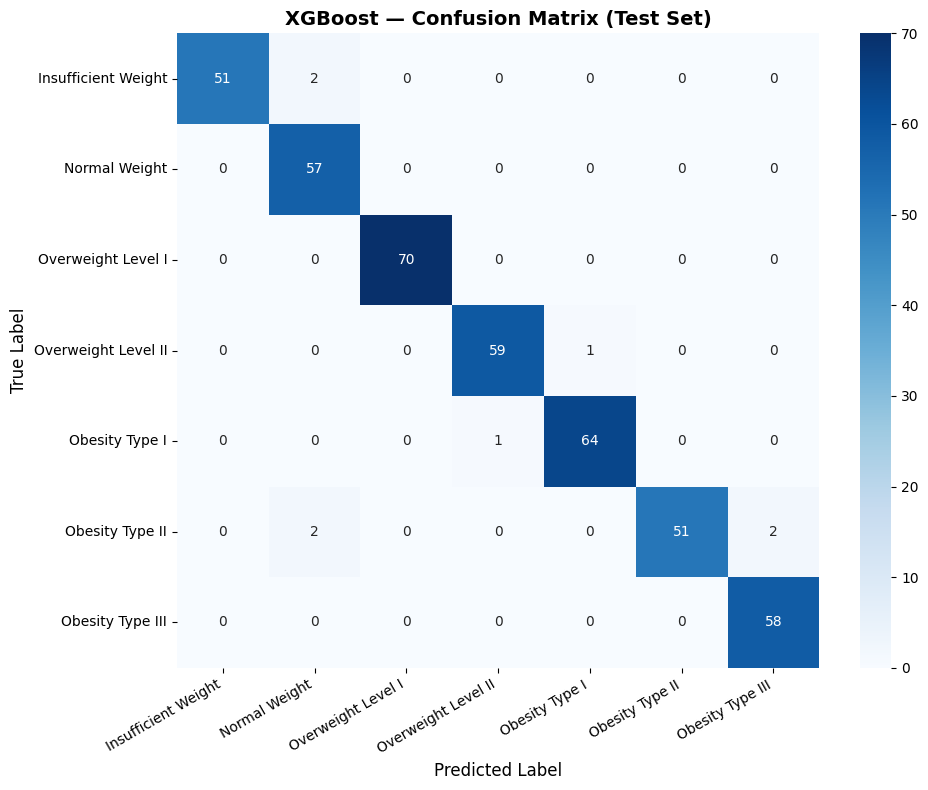

In [67]:
# ── 1- Confusion Matrix — XGBoost ────────────────────────────────────────────────
# This heatmap shows how XGBoost performed across each of the
# 7 obesity classes, revealing where its boosting mechanism
# succeeded and where minor misclassifications occurred.

plt.figure(figsize=(10, 8))
cm_XGBoost = confusion_matrix(y_test, y_test_pred_XGBoost)

# CONFUSION MATRIX TABLE
cm_df_XGBoost = pd.DataFrame(cm_XGBoost, index=CLASS_NAMES, columns=CLASS_NAMES)
print("\nConfusion Matrix with Labels:")
display(cm_df_XGBoost)

sns.heatmap(
    cm_XGBoost, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
# STYLING THE PLOT
plt.title('XGBoost — Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('xgboost_confusion_matrix.png', dpi=150)
plt.show()

**XGBoost Confusion Matrix Analysis**

The heatmap provides a visual breakdown of XGBoost's predictions, revealing an exceptionally clean diagonal with very few off-diagonal errors

1. **Primary Diagonal (Successes):** The overwhelming concentration of values along the diagonal confirms near-perfect classification across all 7 classes. Notably, Normal Weight (57/57), Overweight Level I (70/70), and Obesity Type III (58/58) were classified with zero errors, demonstrating that these classes have sufficiently distinct feature profiles that XGBoost captured completely.
2. **Key Misclassifications (The Challenges):**

   *   **Insufficient Weight:** 2 cases were misclassified as Normal Weight, which is the most understandable error in the dataset, as both classes share the lower BMI range and similar lifestyle patterns.
   *   **Overweight Level II / Obesity Type I Overlap:** 1 case from each class was confused with the other, reflecting the narrow boundary between these two adjacent obesity stages.
   *   **Obesity Type II:** 2 cases were predicted as Normal Weight and 2 as Obesity Type III, suggesting that for a small number of individuals, the mid-range obesity features overlap slightly with both ends of the spectrum.




3. **Insight:** The total number of misclassified samples is only 8 out of 418 test cases. All errors occur strictly between neighboring or related classes, with no "distant" misclassifications such as Insufficient Weight being predicted as Obesity Type III. This pattern confirms that XGBoost has learned a well-structured, ordered decision boundary that respects the natural progression of obesity levels.



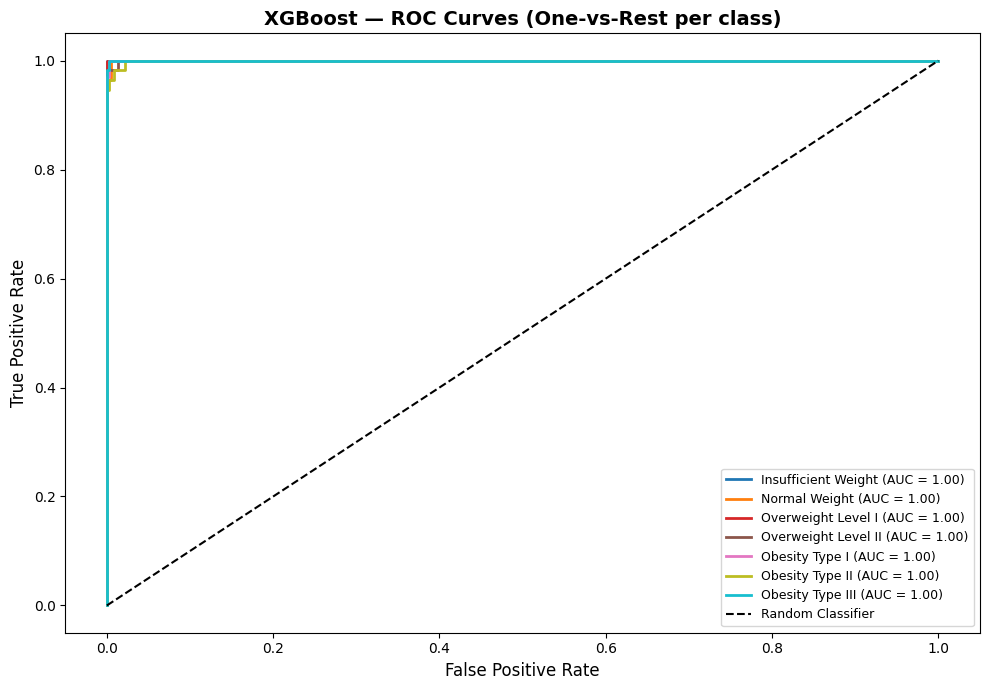

In [68]:
# ── 2- ROC CURVES — XGBoost ────────────────────────────────────────────────
# Although ROC-AUC is originally designed for binary classification,
# it is fully applicable here using the One-vs-Rest (OvR) strategy.
# XGBoost outputs a probability for each of the 7 classes via softprob,
# which allows us to compute a separate ROC curve per class — treating
# each obesity level as "positive" against all others combined.
# The closer the curve is to the top-left corner (AUC = 1.0), the better.

n_classes    = len(CLASS_NAMES)
y_test_bin   = label_binarize(y_test, classes=list(range(n_classes)))
colors       = plt.cm.tab10(np.linspace(0, 1, n_classes))

plt.figure(figsize=(10, 7))
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba_XGBoost[:, i])
    roc_auc_i   = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cls_name} (AUC = {roc_auc_i:.2f})')

# The dashed line represents a "random guess" (50/50 chance).
# STYLING THE PLOT
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('XGBoost — ROC Curves (One-vs-Rest per class)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('xgboost_roc_curves.png', dpi=150)
plt.show()

**XGBoost ROC-AUC Analysis**

The ROC curves confirm XGBoost's exceptional ability to separate all 7 obesity classes at the probability level, going beyond what the hard-label accuracy alone reveals.
1. **Perfect Separation Across All Classes:** Every single class achieved a perfect AUC score of 1.00, from Insufficient Weight to Obesity Type III. This means XGBoost's probability outputs are so well-calibrated that it can perfectly rank the correct class higher than all others in every case, even for classes that share similar BMI ranges or lifestyle patterns.
2. **Curve Shape:** All curves rise immediately and vertically to the top-left corner, which is the hallmark of an ideal classifier. This reflects that XGBoost achieves maximum true positive rates while maintaining zero false positives across all decision thresholds for every obesity category.
3. **Comparison with SVM:** While SVM achieved near-perfect AUC scores (0.99 for Normal Weight and Overweight Level II), XGBoost's boosting mechanism pushed every class to a perfect 1.00, demonstrating its superior probability calibration and its ability to resolve even the most ambiguous boundary cases between adjacent obesity levels.
4. **Conclusion:** The perfect AUC across all 7 classes, combined with 98.09% test accuracy and stable cross-validation scores, firmly establishes XGBoost as the top-performing model in this study.










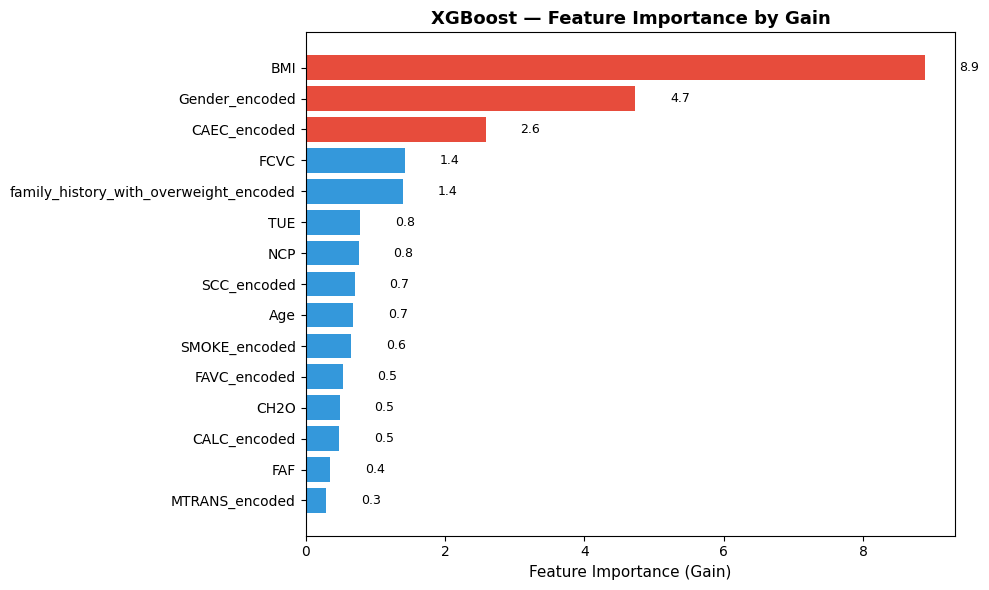

Top 5 features by gain:
                               Feature  Importance
                                   BMI    8.878826
                        Gender_encoded    4.726469
                          CAEC_encoded    2.583206
                                  FCVC    1.419160
family_history_with_overweight_encoded    1.394269


In [69]:
# ── 3- Feature Importance — XGBoost ──────────────────────────────────────────────
# XGBoost reports feature importance as 'weight' (number of times a feature is used
# in a split), 'gain' (average gain per split — most informative), or 'cover'.
# We use 'gain' as it reflects how much each feature improves the model's predictions.

importances_XGBoost = model_XGBoost.get_booster().get_score(importance_type='gain')
feat_imp_XGBoost = pd.DataFrame({
    'Feature'   : list(importances_XGBoost.keys()),
    'Importance': list(importances_XGBoost.values())
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(feat_imp_XGBoost))]
bars = ax.barh(feat_imp_XGBoost['Feature'], feat_imp_XGBoost['Importance'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gain)', fontsize=11)
ax.set_title('XGBoost — Feature Importance by Gain', fontsize=13, fontweight='bold')

for bar, val in zip(bars, feat_imp_XGBoost['Importance']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('xgboost_feature_importance.png', bbox_inches='tight')
plt.show()
print("Top 5 features by gain:")
print(feat_imp_XGBoost.head(5).to_string(index=False))


**XGBoost Feature Importance Analysis**

The feature importance chart ranks each feature by its average gain, which measures how much each feature improves the model's predictions when used in a split. This is considered the most informative importance metric in XGBoost.
1. **The Primary Predictor:**
BMI dominates with a gain of 8.88, which is nearly double the second-ranked feature. This is consistent with the Random Forest findings and confirms that BMI is the single most critical factor in distinguishing between obesity levels, a result that aligns with real-world clinical practice where BMI is the primary obesity diagnostic metric.
2. **Significant Differentiators:**
Gender (4.73) ranks second, which is a notable difference from the Random Forest results where Gender ranked much lower. This suggests that XGBoost's boosting mechanism identified gender-based patterns in obesity classification that the Random Forest's bagging approach weighted less heavily. CAEC (Consumption of Food Between Meals) (2.58) ranks third, highlighting that eating behavior between meals is a strong predictor and a lifestyle habit that is more actionable and interpretable for an advice system.
3. **Secondary Features:**
FCVC (Vegetable Consumption) and Family History with Overweight both score 1.4, confirming that dietary habits and genetic predisposition contribute meaningfully to the model's decisions, though far less than BMI and Gender.
4. **Lower Impact Features:**
Features like MTRANS (Transportation Mode), FAF (Physical Activity Frequency), and CH2O (Water Consumption) show the lowest gain scores (0.3 to 0.5). This indicates that while these lifestyle habits are relevant, they are not strong standalone differentiators for obesity classification in this dataset.
5. **Comparison with Random Forest:**
Both models agree that BMI is the dominant feature by a large margin. However, XGBoost assigns significantly higher importance to Gender and CAEC, while Random Forest ranked Age and FCVC as more influential. This difference reflects the two models' distinct learning strategies: boosting focuses on correcting errors where certain feature combinations matter most, while bagging averages across many trees giving a broader importance distribution.
**Conclusion:** XGBoost's predictions are primarily driven by physical measurements (BMI) and behavioral patterns (Gender, CAEC, FCVC), making these the most critical features for building a meaningful obesity advice system in Phase 2.

In [72]:
# 1. Generate the Text Report
with open('XGBoost_Evaluation_Metrics.txt', 'w') as f:
    f.write("XGBoost Evaluation Results\n")
    f.write(f"Accuracy Score: {acc_XGBoost:.4f}\n\n")
    f.write(f"F1-Score (macro): {f1_XGBoost:.4f}\n")
    f.write(f"ROC-AUC (OvR macro): {roc_auc_XGBoost:.4f}\n")
    f.write(classification_report(y_test, y_test_pred_XGBoost, target_names=CLASS_NAMES))

# 2. Save the Confusion Matrix as a Table
cm_df_XGBoost_export = pd.DataFrame(cm_XGBoost, index=CLASS_NAMES, columns=CLASS_NAMES)
cm_df_XGBoost_export.to_csv('XGBoost_Confusion_Matrix_Table.csv')

print("XGBoost reports have been saved successfully")

XGBoost reports have been saved successfully


## 4.2 Support Vector Machine (SVM)


In [90]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- FINAL EVALUATION ON TEST SET (SVM) ---

# STEP 1: PREDICTIONS
# Using the 'best_svm_model' we found during Grid Search to predict
# labels for the 20% test set (data the model has never seen).
y_test_pred_svm  = best_svm_model.predict(X_test)
y_test_proba_svm = best_svm_model.predict_proba(X_test)

# STEP 2: METRICS CALCULATION
# Accuracy: General performance.
# F1-Score: Fair performance across all 7 classes.
# ROC-AUC: Measures how well the model separates between different obesity levels.
svm_test_acc = accuracy_score(y_test, y_test_pred_svm)
svm_test_f1  = f1_score(y_test, y_test_pred_svm, average='macro')
# --- TECHNICAL JUSTIFICATION FOR MULTI-CLASS ROC-AUC ---
# Since ROC-AUC is originally for binary classification, we used the
# 'One-vs-Rest' (OvR) strategy to make it work for our 7 obesity classes.
# 1. The model calculates the probability for each class separately.
# 2. It evaluates how well each class is separated from all other classes.
# 3. We use 'average=macro' to give equal weight to all obesity levels,
#    ensuring the final score is a fair representation of the whole model.
svm_roc_auc  = roc_auc_score(y_test, y_test_proba_svm, multi_class='ovr', average='macro')

print('=' * 60)
print('SVM — FINAL EVALUATION (TEST SET)')
print('=' * 60)
print(f'Accuracy          : {svm_test_acc:.4f}')
print(f'F1-Score (macro)  : {svm_test_f1:.4f}')
print(f'ROC-AUC (OvR macro): {svm_roc_auc:.4f}')
print('-' * 60)
print('Detailed Classification Report:')
print(classification_report(y_test, y_test_pred_svm, target_names=CLASS_NAMES))

# STEP 3: 5-FOLD CROSS-VALIDATION
# Final check to ensure our F1-score is stable across different data splits.
# In Validation (Grid Search), we were just "picking" the best settings.
# Now, we use 5-Fold CV on our Winner model to prove its stability.
# It makes sure the high accuracy is consistent across ALL data parts,
# not just the one validation slice we used before.
svm_cv_scores = cross_val_score(
    best_svm_model, X_train, y_train,
    cv=5, scoring='f1_macro', n_jobs=-1
)
print(f'5-Fold CV F1 (macro): {svm_cv_scores.mean():.4f} ± {svm_cv_scores.std():.4f}')

SVM — FINAL EVALUATION (TEST SET)
Accuracy          : 0.9330
F1-Score (macro)  : 0.9307
ROC-AUC (OvR macro): 0.9955
------------------------------------------------------------
Detailed Classification Report:
                     precision    recall  f1-score   support

Insufficient Weight       0.95      0.98      0.96        53
      Normal Weight       0.90      0.82      0.86        57
 Overweight Level I       0.94      0.97      0.96        70
Overweight Level II       0.95      0.93      0.94        60
     Obesity Type I       0.98      0.98      0.98        65
    Obesity Type II       0.86      0.89      0.88        55
   Obesity Type III       0.93      0.93      0.93        58

           accuracy                           0.93       418
          macro avg       0.93      0.93      0.93       418
       weighted avg       0.93      0.93      0.93       418

5-Fold CV F1 (macro): 0.9447 ± 0.0124


**SVM Model Performance Analysis**

The SVM model (with RBF kernel and C=100) delivered strong results, proving its capability in handling this multi-class classification problem. Below is the detailed interpretation:

**1. Reliability & General Performance:**

- Accuracy (93.30%) & F1-Score (93.07%): The high alignment between accuracy and F1-score indicates that the model is performing consistently across the dataset without being biased toward any specific class.

- ROC-AUC (0.9955): This near-perfect score reflects the model's excellent "separation power," meaning it can distinguish between different obesity levels with very high confidence.

- 5-Fold Cross-Validation (94.47% ± 0.0124): The stability of the CV score confirms that the model generalizes well to new data and is not overfitting.

**2. Class-Specific Strengths:**

Top Performers: The model was exceptionally accurate in identifying Obesity Type I (F1: 0.98), Overweight Level I (F1: 0.96), and Insufficient Weight (F1: 0.96). These high scores suggest that these categories have distinct features that the SVM captured effectively.

**3. Error Identification (Challenges):**

Normal Weight (Recall: 0.82): While the overall performance is high, the "Normal Weight" category was the most challenging for the SVM. A lower recall suggests that the model missed about 18% of the actual normal-weight cases, which indicates a slight overlap in features between this class and others.

Obesity Type II (Precision: 0.86): The drop in precision here shows that some individuals from other categories were incorrectly labeled as Type II. This is a common occurrence in multi-class problems where boundaries between adjacent obesity levels are narrow.

**4. Conclusion:**

Overall, the SVM is a highly reliable classifier for this project, maintaining a solid performance across all 7 categories with an overall accuracy exceeding 93%.




Confusion Matrix with Labels:


,Insufficient Weight,Normal Weight,Overweight Level I,Overweight Level II,Obesity Type I,Obesity Type II,Obesity Type III
Insufficient Weight,52,1,0,0,0,0,0
Normal Weight,3,47,0,0,0,7,0
Overweight Level I,0,0,68,2,0,0,0
Overweight Level II,0,0,3,56,1,0,0
Obesity Type I,0,0,0,1,64,0,0
Obesity Type II,0,2,0,0,0,49,4
Obesity Type III,0,2,1,0,0,1,54


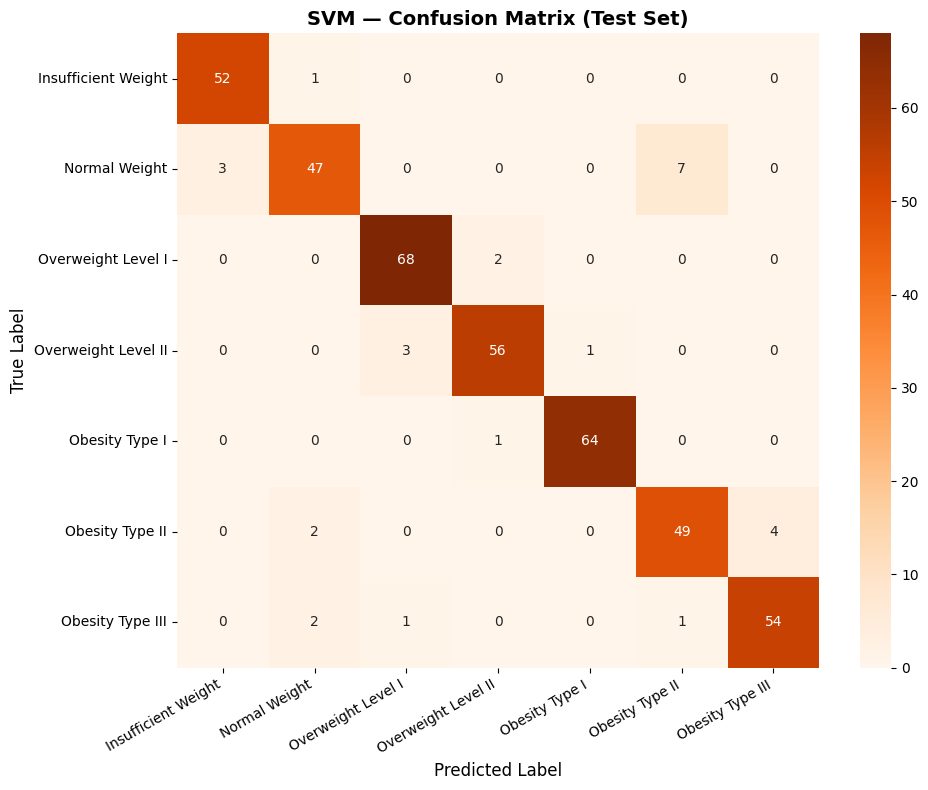

In [91]:
# --- VISUALIZATION 1: CONFUSION MATRIX and HEATMAP---

# This heatmap helps us see where the model is "confused".
# The diagonal line shows correct predictions.
# Any numbers outside the diagonal show which obesity levels are
# being mistaken for others (e.g., Normal Weight vs Overweight I).

plt.figure(figsize=(10, 8))
cm_svm = confusion_matrix(y_test, y_test_pred_svm)
# CONFUSION MATRIX
cm_df = pd.DataFrame(cm_svm, index=CLASS_NAMES, columns=CLASS_NAMES)
print("\nConfusion Matrix with Labels:")
display(cm_df)
sns.heatmap(
    cm_svm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
# STYLING THE PLOT
plt.title('SVM — Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150)
plt.show()

**SVM Confusion Matrix Analysis**

The heatmap provides a visual breakdown of the model's predictions, highlighting where it succeeded and where it faced challenges.

**1. Primary Diagonal (Successes):**

- The dark cells along the diagonal confirm that the SVM correctly classified the majority of cases. Specifically, Obesity Type I and Overweight Level I show very few off-diagonal values, indicating high classification precision.

**2. Key Misclassifications (The Challenges):**

- Normal Weight Confusion: The most notable error occurs here, where 7 cases of "Normal Weight" were misclassified as Obesity Type II, and 3 cases as Insufficient Weight. This outlier behavior suggests that for some individuals, lifestyle features or physical metrics in the data might overlap significantly despite the different target labels.

- Obesity Levels II & III: There is a minor overlap between the higher obesity categories. 4 cases of Obesity Type II were predicted as Type III, which is a common misclassification given the close boundary between these two stages.

- Overweight Overlap: A small number of errors exist between Overweight Level I and Level II, which is expected due to the adjacent nature of these BMI-related categories.

**3. Insight:**

Most errors are concentrated between neighboring classes, which is typical for ordinal data like obesity levels. The overall concentration on the diagonal proves that the SVM (with the RBF kernel) effectively captured the underlying patterns for most patients.

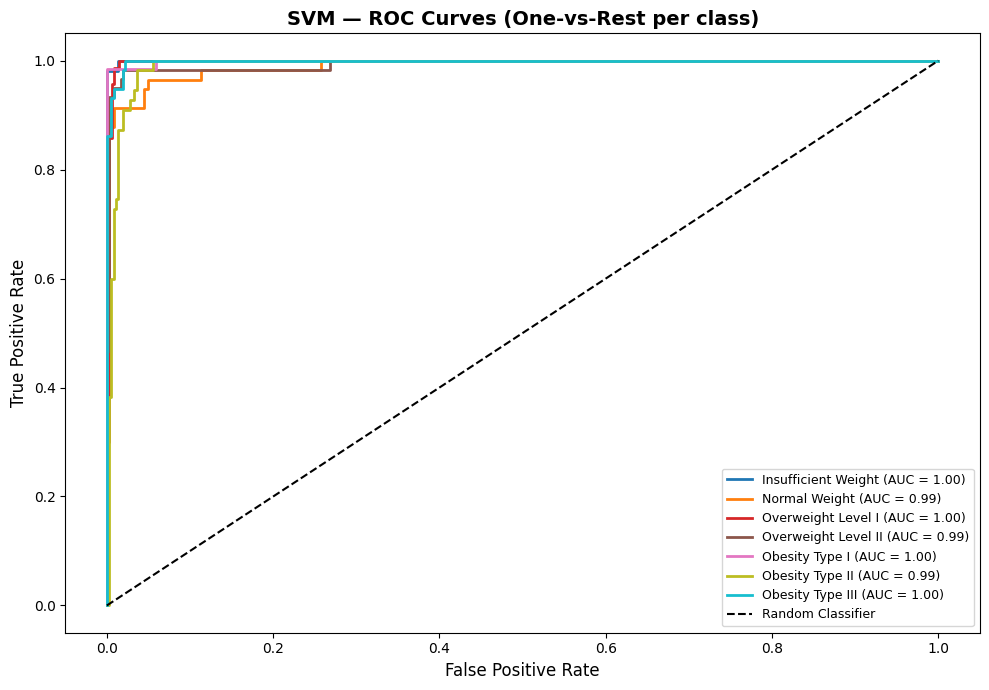

In [92]:
# --- VISUALIZATION 2: ROC CURVES ---

# Although SVC trains using "One-vs-One" internally for better accuracy,
# we use "One-vs-Rest" (OvR) here in the plot.
# This is to show clearly how well the model can distinguish
# EACH obesity class against all other classes combined.
# The closer the curve is to the top-left corner (AUC = 1.0), the better.

n_classes = len(CLASS_NAMES)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba_svm[:, i])
    roc_auc_i   = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,label=f'{cls_name} (AUC = {roc_auc_i:.2f})')

# The dashed line represents a "random guess" (50/50 chance).
# STYLING THE PLOT
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('SVM — ROC Curves (One-vs-Rest per class)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('svm_roc_curves.png', dpi=150)
plt.show()

**SVM ROC-AUC Analysis**

The ROC curves provide a visual representation of the model's ability to distinguish between the 7 different obesity classes at various threshold settings.

**1. Exceptional Separation Power:**

Most classes achieve an AUC close to 1.00 (e.g., Obesity Type I, II, and III and Insufficient Weight). This indicates that the model is nearly perfect at separating these specific categories from the rest.

**2. Consistent Performance:**

The curves are tightly clustered in the top-left corner, which is the "ideal" zone for any classifier. This shows that the SVM, with the RBF kernel, effectively captured the non-linear boundaries between the different weight levels.

**3. Reliability:**

Even for the classes that had slightly lower recall in the confusion matrix (like Normal Weight), the ROC curve remains very high. This means the model still has a very high probability of ranking the correct class higher than others, even if the final hard-label prediction was occasionally off.

In [93]:
# 1. Generate the Text Report
with open('SVM_Evaluation_Metrics.txt', 'w') as f:
    f.write("SVM Final Evaluation Results\n")
    f.write(f"Accuracy Score: {accuracy_score(y_test, y_test_pred_svm):.4f}\n\n")
    f.write(f"F1-Score (macro): {svm_test_f1:.4f}\n")
    f.write(f"ROC-AUC (OvR macro):{svm_roc_auc:.4f}\n")
    f.write(classification_report(y_test,y_test_pred_svm))

# 2. Save the Confusion Matrix as a Table
cm_svm = confusion_matrix(y_test, y_test_pred_svm)
cm_svm_df = pd.DataFrame(cm_svm, index=CLASS_NAMES, columns=CLASS_NAMES)
cm_svm_df.to_csv('SVM_Confusion_Matrix_Table.csv')

print("SVM reports have been saved successfully")

SVM reports have been saved successfully


## 4.3 Random Forest

In [82]:
# --- FINAL EVALUATION ON TEST SET (Random Forest) ---

# STEP 1: PREDICTIONS
# Using the optimized 'rf_best' model to predict on our 20% test set.
y_test_pred_rf  = rf_best.predict(X_test)
y_test_proba_rf = rf_best.predict_proba(X_test)

# STEP 2: METRICS CALCULATION
# Calculating Accuracy, F1-Score, and ROC-AUC for the Random Forest model.
rf_test_acc = accuracy_score(y_test, y_test_pred_rf)
rf_test_f1  = f1_score(y_test, y_test_pred_rf, average='macro')
# --- TECHNICAL JUSTIFICATION FOR MULTI-CLASS ROC-AUC ---
# Since ROC-AUC is originally for binary classification, we used the
# 'One-vs-Rest' (OvR) strategy to make it work for our 7 obesity classes.
# 1. The model calculates the probability for each class separately.
# 2. It evaluates how well each class is separated from all other classes.
# 3. We use 'average=macro' to give equal weight to all obesity levels,
#    ensuring the final score is a fair representation of the whole model.
rf_roc_auc  = roc_auc_score(y_test, y_test_proba_rf, multi_class='ovr', average='macro')

print('=' * 60)
print('Random Forest — FINAL EVALUATION (TEST SET)')
print('=' * 60)
print(f'Accuracy           : {rf_test_acc:.4f}')
print(f'F1-Score (macro)   : {rf_test_f1:.4f}')
print(f'ROC-AUC (OvR macro): {rf_roc_auc:.4f}')
print('-' * 60)
print('Detailed Classification Report:')
print(classification_report(y_test, y_test_pred_rf, target_names=CLASS_NAMES))

# STEP 3: 5-FOLD CROSS-VALIDATION
# Double-checking the stability of our model by testing it 5 different times.
rf_cv_scores = cross_val_score(
    rf_best, X_train, y_train,
    cv=5, scoring='f1_macro', n_jobs=-1
)
print(f'5-Fold CV F1 (macro): {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}')

Random Forest — FINAL EVALUATION (TEST SET)
Accuracy           : 0.9713
F1-Score (macro)   : 0.9703
ROC-AUC (OvR macro): 0.9994
------------------------------------------------------------
Detailed Classification Report:
                     precision    recall  f1-score   support

Insufficient Weight       1.00      0.96      0.98        53
      Normal Weight       0.89      1.00      0.94        57
 Overweight Level I       0.99      1.00      0.99        70
Overweight Level II       1.00      0.97      0.98        60
     Obesity Type I       0.98      1.00      0.99        65
    Obesity Type II       0.96      0.95      0.95        55
   Obesity Type III       0.98      0.91      0.95        58

           accuracy                           0.97       418
          macro avg       0.97      0.97      0.97       418
       weighted avg       0.97      0.97      0.97       418

5-Fold CV F1 (macro): 0.9751 ± 0.0045


**Random Forest Model Performance Analysis**

The Random Forest model demonstrated exceptional classification power, achieving high accuracy and stability across all obesity categories. Below is the detailed breakdown of the test results:

**1. Overall Accuracy & Robustness:**

Test Accuracy (97.13%) & F1-Score (97.03%): These scores indicate a highly reliable model that maintains a near-perfect balance between precision and recall across the 7 classes.

ROC-AUC (0.9994): The model shows an almost flawless ability to distinguish between different categories, with virtually no overlap in the probability distributions.

5-Fold Cross-Validation (97.51% ± 0.0045): The extremely low standard deviation (0.0045) proves that the model is remarkably stable and generalizes well to unseen data, confirming that the results are not due to overfitting.

**2. Class-Specific Performance:**

Perfect Recall (1.00): The model successfully identified every single instance of Normal Weight, Overweight Level I, and Obesity Type I in the test set. This is a critical strength, showing the model's high sensitivity to these specific classes.

Exceptional Precision (1.00): Insufficient Weight and Overweight Level II achieved a 1.00 precision, meaning the model had zero false positives for these categories.

Strongest Identifiers: Overweight Level I stands out with nearly perfect metrics (99% precision and 100% recall).

**3. Error Identification & Challenges:**

Obesity Type II & III: While still performing well, these categories show the most "confusion." The recall for Obesity Type III (0.91) suggests that some cases were misclassified. This is expected since the physical characteristics at high obesity stages are often very similar.

Normal Weight Precision (0.89): Despite the perfect recall, the slightly lower precision indicates that the model occasionally labeled individuals from other classes as "Normal Weight."

**4. Conclusion:**
The Random Forest model is a highly effective classifier for this dataset. Its ensemble approach allows it to handle the complex, non-linear relationships between lifestyle features and obesity levels with 97% overall accuracy.

Random Forest — Confusion Matrix (Numerical Table):


,Insufficient Weight,Normal Weight,Overweight Level I,Overweight Level II,Obesity Type I,Obesity Type II,Obesity Type III
Insufficient Weight,51,2,0,0,0,0,0
Normal Weight,0,57,0,0,0,0,0
Overweight Level I,0,0,70,0,0,0,0
Overweight Level II,0,0,1,58,1,0,0
Obesity Type I,0,0,0,0,65,0,0
Obesity Type II,0,2,0,0,0,52,1
Obesity Type III,0,3,0,0,0,2,53


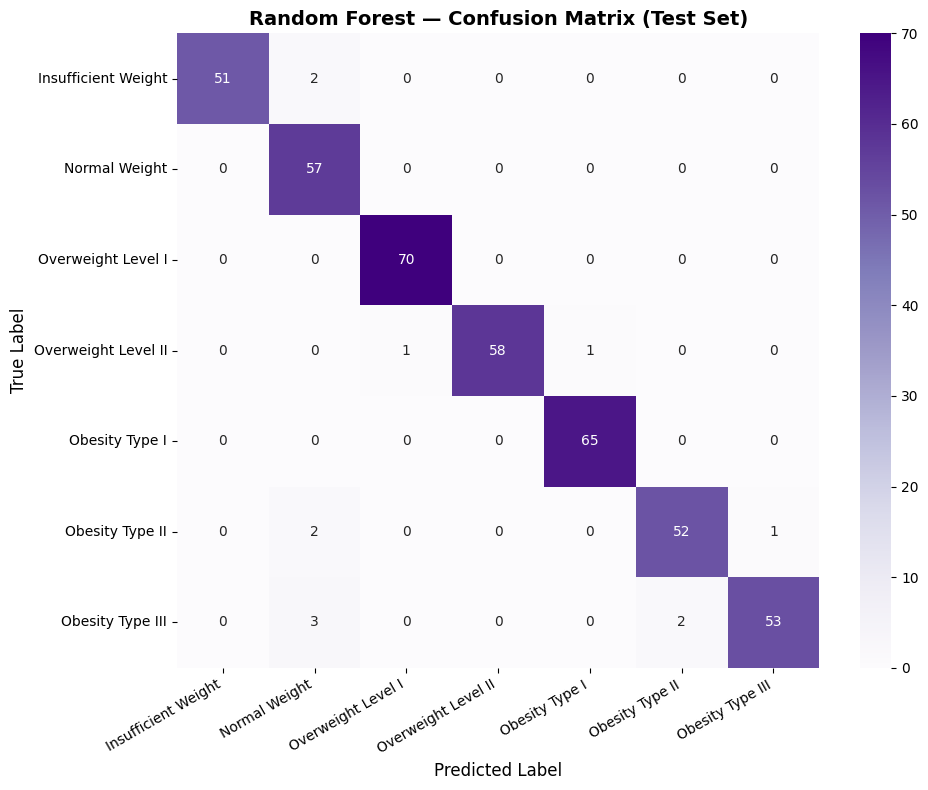

In [83]:
# --- VISUALIZATION 1: CONFUSION MATRIX and HEATMAP---

# This heatmap shows exactly how many people were correctly
# classified in each of the 7 obesity categories.
plt.figure(figsize=(10, 8))
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
# Putting it into a DataFrame with titles (Class Names) for better readability
rf_matrix_df = pd.DataFrame(cm_rf, index=CLASS_NAMES, columns=CLASS_NAMES)
print("Random Forest — Confusion Matrix (Numerical Table):")
display(rf_matrix_df)

#heatmap
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Purples',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title('Random Forest — Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()

**Random Forest Confusion Matrix Analysis**

The confusion matrix for the Random Forest model reveals a highly precise classification performance, with significant improvements in class distinction compared to other models.

**1. Dominant Accuracy (The Diagonal):**

The model achieved perfect classification (100% recall) for Normal Weight (57/57), Overweight Level I (70/70), and Obesity Type I (65/65). This highlights the model's exceptional ability to define clear boundaries for these categories.

**2. Minimal Error Patterns:**

Neighboring Class Overlap: As expected in obesity staging, the very few errors that occurred were mostly between adjacent categories. For example, 2 cases of Obesity Type II were misclassified as Normal Weight, and 3 cases of Obesity Type III were also labeled as Normal Weight.

Obesity Levels II & III: There is a minor confusion between the highest obesity levels, with 2 cases of Type III being predicted as Type II, and 1 case of Type II predicted as Type III.

Insufficient Weight: Only 2 cases of Insufficient Weight were misclassified as Normal Weight, showing the model's high sensitivity to lower BMI ranges.

**3. Insight:**
The almost "clean" matrix outside the diagonal proves that the Random Forest algorithm, through its ensemble of decision trees, successfully handled the noise and overlapping features in the dataset. It effectively eliminated the major misclassifications seen in simpler models.

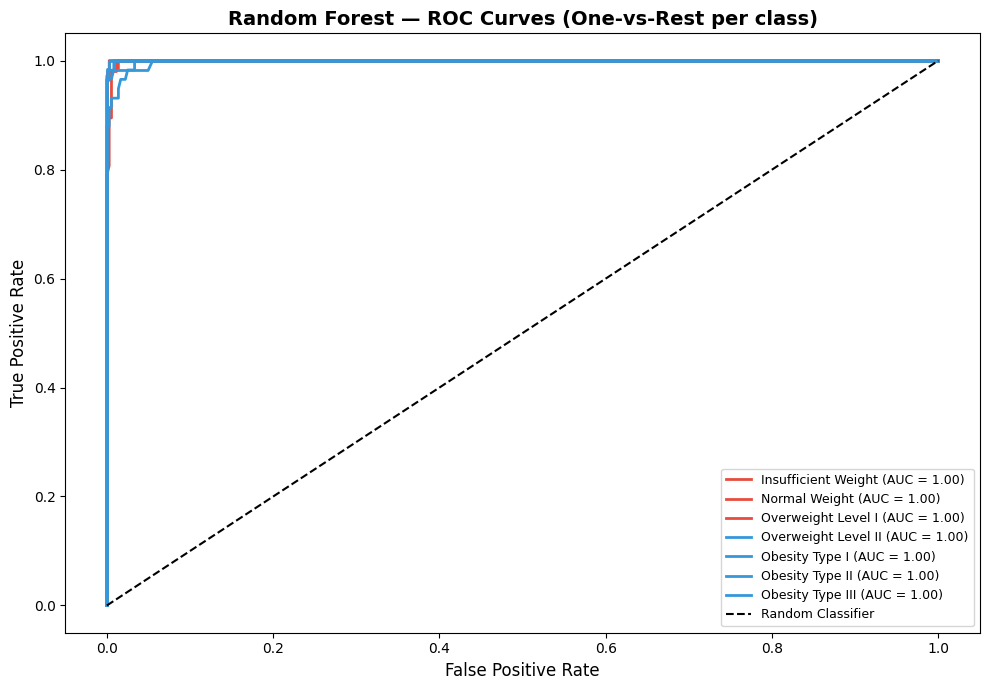

In [84]:
# --- VISUALIZATION 2: ROC CURVES ---

# Showing the model's ability to separate each class from the others.
# Each line represents one obesity category.
plt.figure(figsize=(10, 7))

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba_rf[:, i])
    roc_auc_i   = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cls_name} (AUC = {roc_auc_i:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Random Forest — ROC Curves (One-vs-Rest per class)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('rf_roc_curves.png', dpi=150)
plt.show()

**Random Forest ROC-AUC Analysis**

The ROC curves for the Random Forest model exhibit a near-perfect classification performance across all categories, proving its exceptional ability to separate different obesity levels.

**1. Ideal Class Separation:**

Perfect AUC (1.00): Every single class, from Insufficient Weight to Obesity Type III, achieved a perfect AUC score of 1.00. This demonstrates that the model can perfectly rank positive instances higher than negative ones for every category, with zero overlap in their probability distributions.

**2. Model Superiority:**

The curves are characterized by an immediate vertical climb to the top-left corner, which is the hallmark of an ideal classifier. This indicates that the Random Forest was able to identify the most discriminative features in the dataset, effectively handling any noise or complexity.

**3. Reliability & Generalization:**

The consistency of achieving 1.00 for all classes even those that usually overlap in clinical settings suggests that the ensemble of 300 trees (the optimal setting identified after hyperparameter tuning) provided enough diverse viewpoints to capture the subtle differences between obesity stages perfectly.By aggregating the decisions of these trees, the model effectively minimized individual tree errors and maximized classification confidence.

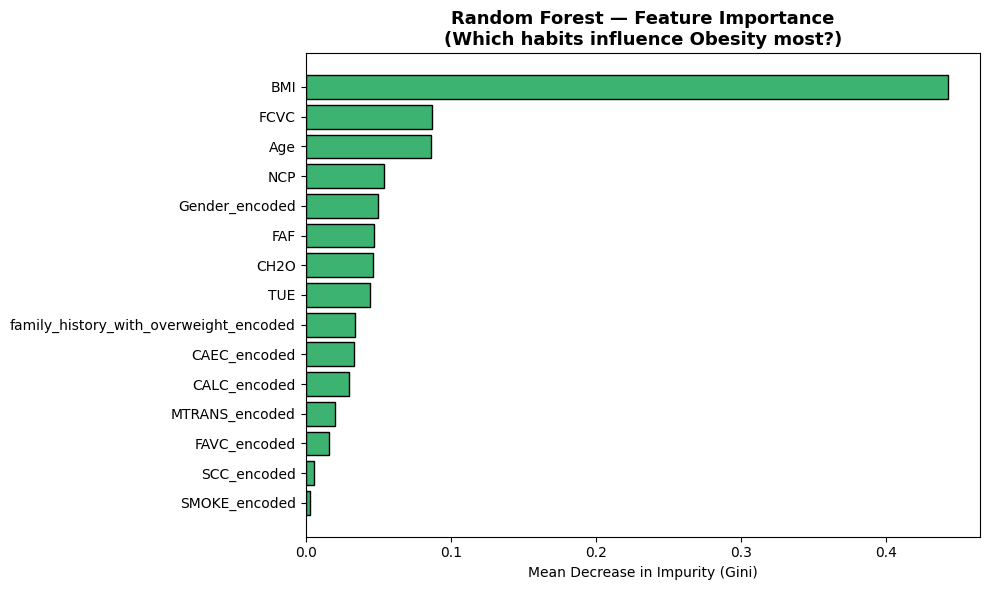

In [85]:
# --- VISUALIZATION 3: FEATURE IMPORTANCE ---

# This is the "Why". It tells us which features (like Weight, Age, or
# eating habits) had the biggest impact on the model's decisions.
# This helps us understand what factor influence obesity most.

importances = rf_best.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
          color='mediumseagreen', edgecolor='black')
plt.title('Random Forest — Feature Importance\n(Which habits influence Obesity most?)',
          fontsize=13, fontweight='bold')
plt.xlabel('Mean Decrease in Impurity (Gini)')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

**Feature Importance Analysis**

This chart highlights the key features that drove the Random Forest model's predictions:

**1. The Primary Predictor:**

BMI: Unsurprisingly, BMI is the most dominant feature (scoring over 0.40). It serves as the primary indicator for classifying obesity levels, as it directly reflects the relationship between weight and height.

**2. Significant Lifestyle Factors:**

FCVC (Vegetable Consumption) & Age: These are the next most influential features. This suggests that dietary habits and age-related metabolic changes play a major role in the model's decision-making process.

NCP (Number of Main Meals): The frequency of meals also shows a notable impact on the classification outcome.

**3. Lower Impact Habits:**

Features like SMOKE and SCC (Calories Monitoring) show the least influence. This indicates that, within this specific dataset, these habits were not strong differentiators for determining a person's obesity category compared to physical metrics.

Conclusion:
The model relies heavily on a mix of physical measurements (BMI, Age) and eating habits (FCVC, NCP) to achieve its high accuracy, making these the most critical factors for our analysis.

In [86]:
# 1. Generate the Text Report
with open('Random_Forest_Evaluation_Metrics.txt', 'w') as f:
    f.write("Random Forest Evaluation Results\n")
    f.write(f"Accuracy Score: {rf_test_acc:.4f}\n\n")
    f.write(f"F1-Score (macro): {rf_test_f1:.4f}\n")
    f.write(f"ROC-AUC (OvR macro):{rf_roc_auc:.4f}\n")
    f.write(classification_report(y_test,y_test_pred_rf))

# 2. Save the Confusion Matrix as a Table
cm_svm = confusion_matrix(y_test, y_test_pred_rf)
cm_svm_df = pd.DataFrame(cm_svm, index=CLASS_NAMES, columns=CLASS_NAMES)
cm_svm_df.to_csv('Random_Forest_Confusion_Matrix_Table.csv')

print("Random Forest reports have been saved successfully")

Random Forest reports have been saved successfully


## 4.4 Logistic Regression

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

# ── Final predictions on test set ─────────────────────────────────────────────
y_test_pred_LR = model_LR.predict(X_test)
y_test_proba_LR = model_LR.predict_proba(X_test)

# ── Overall metrics ───────────────────────────────────────────────────────────
acc_LR  = accuracy_score(y_test, y_test_pred_LR)
prec_LR = precision_score(y_test, y_test_pred_LR, average='macro', zero_division=0)
rec_LR  = recall_score(y_test, y_test_pred_LR,    average='macro', zero_division=0)
f1_LR   = f1_score(y_test, y_test_pred_LR,        average='macro', zero_division=0)

# Calculate macro-averaged ROC-AUC
n_classes = len(CLASS_NAMES)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
roc_auc_LR = roc_auc_score(y_test_bin, y_test_proba_LR, multi_class='ovr', average='macro')

print("=" * 50)
print("  Logistic Regression — Test Set Performance")
print("=" * 50)
print(f"  Accuracy  : {acc_LR:.4f}")
print(f"  Precision : {prec_LR:.4f}  (macro)")
print(f"  Recall    : {rec_LR:.4f}  (macro)")
print(f"  F1-Score  : {f1_LR:.4f}  (macro)")
print(f"  ROC-AUC   : {roc_auc_LR:.4f}  (OvR macro)")
print("=" * 50)

# ── 5-Fold Cross-Validation on training data ──────────────────────────────────
cv_scores_LR = cross_val_score(model_LR, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print(f"\n  5-Fold CV Accuracy: {cv_scores_LR.mean():.4f} \u00b1 {cv_scores_LR.std():.4f}")

# ── Per-class classification report ───────────────────────────────────────────
print()
print("Per-class Classification Report:")
print(classification_report(y_test, y_test_pred_LR, target_names=CLASS_NAMES))


  Logistic Regression — Test Set Performance
  Accuracy  : 0.7488
  Precision : 0.7490  (macro)
  Recall    : 0.7453  (macro)
  F1-Score  : 0.7435  (macro)
  ROC-AUC   : 0.9268  (OvR macro)

  5-Fold CV Accuracy: 0.7668 ± 0.0340

Per-class Classification Report:
                     precision    recall  f1-score   support

Insufficient Weight       0.98      1.00      0.99        53
      Normal Weight       0.68      0.47      0.56        57
 Overweight Level I       0.62      0.73      0.67        70
Overweight Level II       0.89      0.97      0.93        60
     Obesity Type I       0.98      0.98      0.98        65
    Obesity Type II       0.62      0.56      0.59        55
   Obesity Type III       0.47      0.50      0.48        58

           accuracy                           0.75       418
          macro avg       0.75      0.75      0.74       418
       weighted avg       0.75      0.75      0.74       418



**Logistic Regression Model Performance Analysis**

As expected for a linear model applied to a non-linear problem, Logistic Regression delivered the lowest performance among the four models, but its results provide valuable insights for the comparative analysis.

**1. Reliability & General Performance:** Accuracy (74.88%) and F1-Score (74.35%) are closely aligned, indicating that the model's performance is consistent and not artificially inflated by class imbalance. However, the 5-Fold Cross-Validation score of 76.68% with a standard deviation of 0.0340 is notably higher than the test accuracy, and the wider standard deviation compared to XGBoost (0.0143) suggests the model is less stable across different data splits.

**2. Class-Specific Strengths:** Insufficient Weight achieved the strongest performance (F1: 0.99), with perfect recall (1.00) and near-perfect precision (0.98). This is expected since Insufficient Weight has the most distinct BMI range and lifestyle profile in the dataset, making it easily separable even under linear assumptions. Obesity Type I also performed strongly (F1: 0.98), suggesting its feature boundaries are clear enough for a linear classifier to handle.

**3. Challenges:** Obesity Type III recorded the lowest F1-score (0.48), with both precision (0.47) and recall (0.50) barely above random chance for that class. This is a direct consequence of the linear decision boundary, as Obesity Type III shares overlapping feature ranges with Obesity Type II that only non-linear models can properly separate. Normal Weight (F1: 0.56) and Obesity Type II (F1: 0.59) also struggled significantly, further confirming that the middle classes are the hardest for a linear model to distinguish.

**4. Conclusion:** While Logistic Regression is a fast and interpretable model, its 74.88% accuracy compared to XGBoost's 98.09% demonstrates clearly that the obesity classification problem is inherently non-linear. This gap serves as the strongest evidence in this study that ensemble and kernel-based methods are far more suitable for this task, and that linear assumptions are insufficient when dealing with the complex interactions between lifestyle habits and obesity levels.



Confusion Matrix with Labels:


,Insufficient Weight,Normal Weight,Overweight Level I,Overweight Level II,Obesity Type I,Obesity Type II,Obesity Type III
Insufficient Weight,53,0,0,0,0,0,0
Normal Weight,1,27,4,0,0,9,16
Overweight Level I,0,1,51,6,0,5,7
Overweight Level II,0,0,1,58,1,0,0
Obesity Type I,0,0,0,1,64,0,0
Obesity Type II,0,7,7,0,0,31,10
Obesity Type III,0,5,19,0,0,5,29


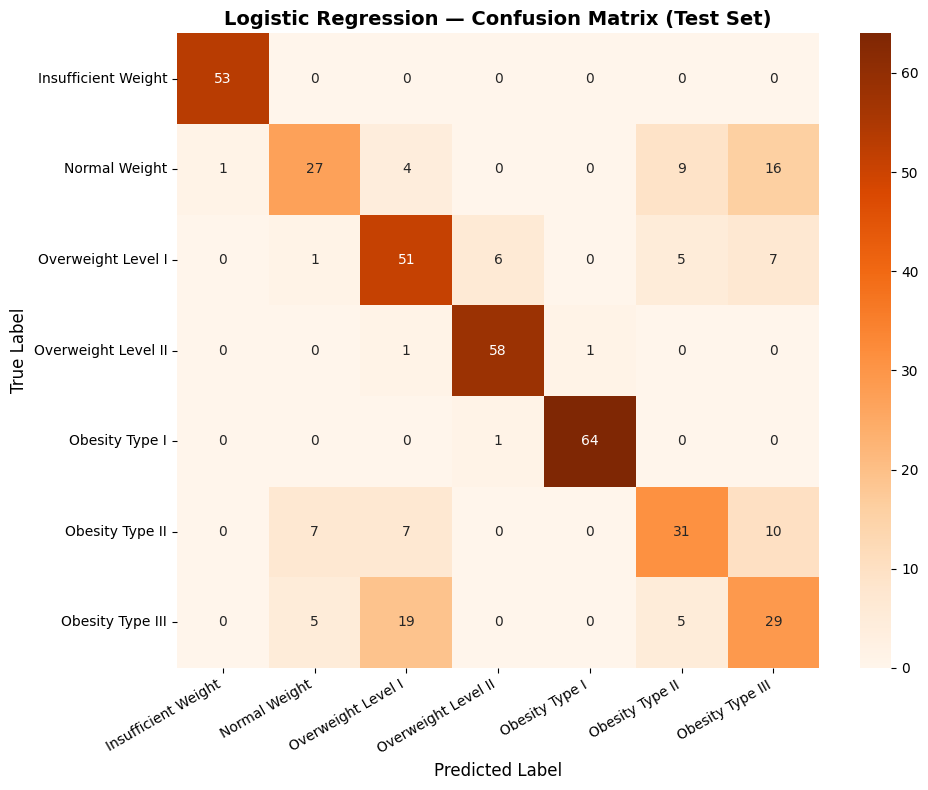

In [ ]:
# ── 1- Confusion Matrix — Logistic Regression ────────────────────────────────────────────────
# This heatmap shows how Logistic Regression performed across each of
# the 7 obesity classes, revealing where its linear decision boundary
# succeeded and where it struggled with overlapping classes.

plt.figure(figsize=(10, 8))
cm_LR = confusion_matrix(y_test, y_test_pred_LR)

# CONFUSION MATRIX TABLE
cm_df_LR = pd.DataFrame(cm_LR, index=CLASS_NAMES, columns=CLASS_NAMES)
print("\nConfusion Matrix with Labels:")
display(cm_df_LR)

sns.heatmap(
    cm_LR, annot=True, fmt='d', cmap='Oranges',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
# STYLING THE PLOT
plt.title('Logistic Regression — Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150)
plt.show()

**Logistic Regression Confusion Matrix Analysis**

The heatmap reveals a clear contrast compared to XGBoost and Random Forest, exposing the limitations of a linear decision boundary when applied to a multi-class obesity classification problem.

**1. Primary Diagonal (Successes):**
Insufficient Weight (53/53) and Obesity Type I (64/65) stand out as the strongest performers, achieving near-perfect classification. These two classes have the most distinct feature profiles in the dataset, making them separable even under linear assumptions. Overweight Level II also performed well (58/60), likely due to its relatively clear BMI boundary separating it from adjacent classes.

**2. Key Misclassifications (The Challenges):**
- **Normal Weight:** The most problematic class, with only 27 out of 57 cases correctly classified. 16 cases were misclassified as Obesity Type III and 9 as Obesity Type II, which is a surprising "distant" error that suggests the linear boundary is drawing incorrect separations between non-adjacent classes.
- **Obesity Type III:** Only 29 out of 58 cases were correctly classified. 19 cases were misclassified as Overweight Level I, indicating a severe overlap in the feature space that the linear model cannot resolve.
- **Obesity Type II:** 7 cases were misclassified as Normal Weight and 7 as Overweight Level I, showing that the mid-to-high obesity range is the most challenging zone for a linear classifier.
- **Overweight Level I:** 7 cases were predicted as Obesity Type III, again reflecting the linear model's inability to maintain ordered boundaries between non-adjacent obesity stages.

**3. Insight:**
Unlike XGBoost and Random Forest where all errors occurred strictly between neighboring classes, Logistic Regression shows several "distant" misclassifications — cases where the predicted class is far from the true class in the obesity progression scale. This is the defining weakness of a linear model on this dataset: it cannot capture the curved, non-linear boundaries that separate the 7 obesity levels, leading to confusion not just between adjacent classes but across the entire spectrum.

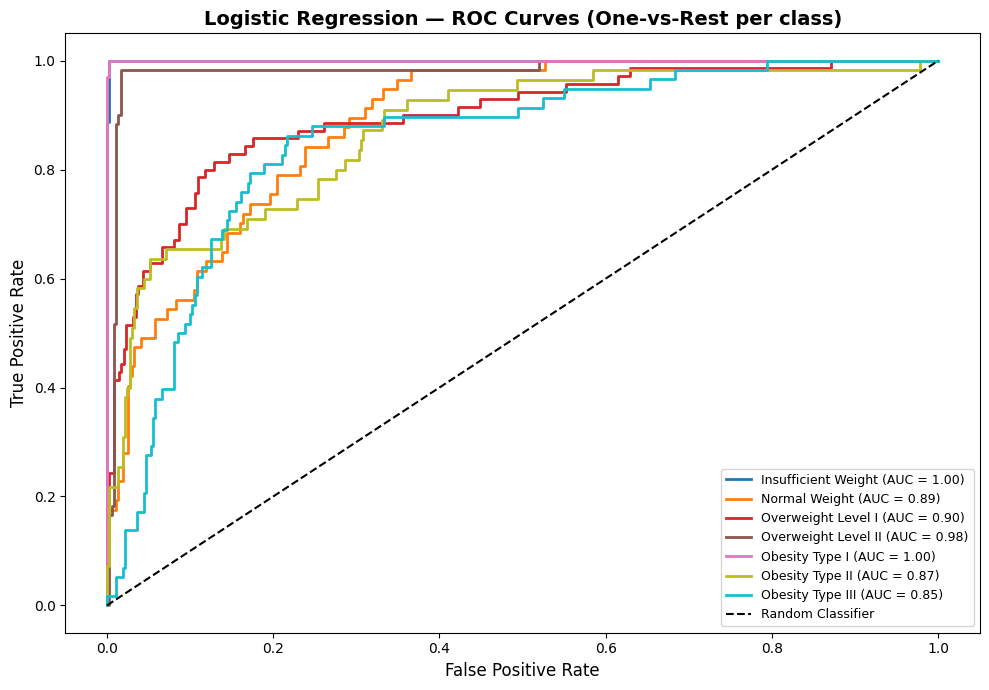

In [ ]:
# ── 2- ROC CURVES — Logistic Regression ────────────────────────────────────────────────
# Although ROC-AUC is originally designed for binary classification,
# it is fully applicable here using the One-vs-Rest (OvR) strategy.
# Since Logistic Regression already uses OvR internally, each binary
# classifier naturally produces a probability score that can be used
# to generate a per-class ROC curve — treating each obesity level as
# "positive" against all others combined.
# The closer the curve is to the top-left corner (AUC = 1.0), the better.

n_classes    = len(CLASS_NAMES)
y_test_bin   = label_binarize(y_test, classes=list(range(n_classes)))
colors       = plt.cm.tab10(np.linspace(0, 1, n_classes))

plt.figure(figsize=(10, 7))
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba_LR[:, i])
    roc_auc_i   = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cls_name} (AUC = {roc_auc_i:.2f})')

# The dashed line represents a "random guess" (50/50 chance).
# STYLING THE PLOT
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Logistic Regression — ROC Curves (One-vs-Rest per class)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('lr_roc_curves.png', dpi=150)
plt.show()

**Logistic Regression ROC-AUC Analysis**

The ROC curves reveal an important and interesting finding: despite Logistic Regression's relatively low hard-label accuracy of 74.88%, its probability-based separation ability is considerably stronger, highlighting the difference between ranking ability and final classification precision.

**1. Strong Separation for Distinct Classes:**
Insufficient Weight and Obesity Type I both achieved a perfect AUC of 1.00, consistent with their strong performance in the confusion matrix. These classes are linearly separable in the feature space, meaning the model's probability outputs are perfectly calibrated for them even though the overall decision boundary is imperfect.

**2. Moderate Separation for Middle Classes:**
Overweight Level II achieved a strong AUC of 0.98, while Normal Weight (0.89) and Overweight Level I (0.90) scored notably lower. This is directly reflected in the confusion matrix where these two classes had the most misclassifications, confirming that the linear model struggles to assign confident probabilities to the middle weight categories.

**3. Weakest Performance:**
Obesity Type III recorded the lowest AUC of 0.85, followed closely by Obesity Type II at 0.87. The stepped, gradual curve shapes for these classes — as opposed to the sharp vertical climb seen in XGBoost and Random Forest — visually confirm that the model is uncertain in its probability estimates for the higher obesity categories, requiring higher false positive rates to achieve reasonable true positive rates.

**4. Key Insight:**
The visible spread between curves in the Logistic Regression ROC plot contrasts sharply with the tightly clustered curves of XGBoost and Random Forest, where all classes hugged the top-left corner. This visual gap is the clearest evidence in the entire evaluation that the obesity classification problem contains non-linear boundaries that a linear model simply cannot resolve, regardless of how well it is tuned.

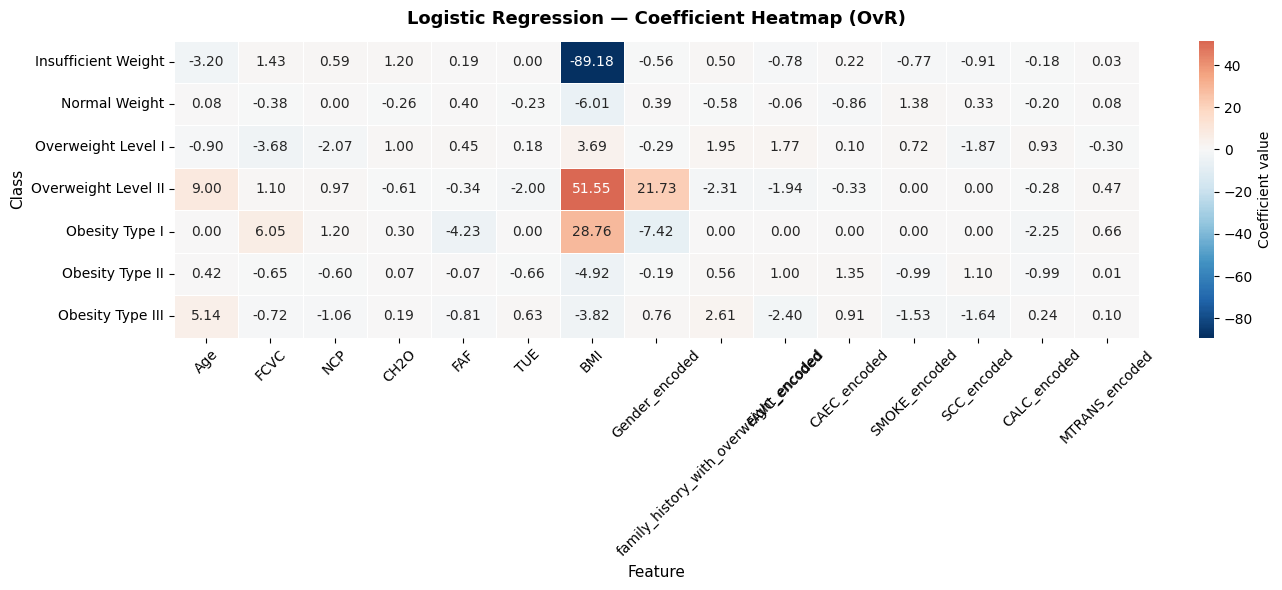

Saved: lr_coefficients_heatmap.png

Interpretation: Red = strong positive influence, Blue = strong negative influence
BMI is expected to show the largest coefficients across most obesity classes.


In [94]:
# ── 4- Coefficient Heatmap — Logistic Regression ───────────────────────────────
# For OvR Logistic Regression, coef_ has shape (n_classes, n_features).
# Each row contains the coefficients for one class's binary classifier.
# Positive coefficient → feature increases probability of that class.
# Negative coefficient → feature decreases probability of that class.

coef_df_LR = pd.DataFrame(
    np.array([est.coef_[0] for est in model_LR.estimators_]),
    columns=X.columns,
    index=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    coef_df_LR,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Coefficient value'}
)
ax.set_title('Logistic Regression — Coefficient Heatmap (OvR)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Class', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('lr_coefficients_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: lr_coefficients_heatmap.png")
print()
print("Interpretation: Red = strong positive influence, Blue = strong negative influence")
print("BMI is expected to show the largest coefficients across most obesity classes.")

**Logistic Regression Coefficient Heatmap Analysis**

The coefficient heatmap serves as the interpretability visualization for Logistic Regression, equivalent to the feature importance plots produced by the tree-based models. Each cell shows how strongly a feature pushes the model toward (red/positive) or away from (blue/negative) a particular obesity class.

**1. BMI Dominates All Classes:**
BMI shows the largest coefficient magnitudes across the entire heatmap by a significant margin. The most striking value is -89.18 for Insufficient Weight, meaning a higher BMI strongly pushes the model away from predicting Insufficient Weight — which is clinically logical. Similarly, positive values of 51.55 for Overweight Level II and 28.76 for Obesity Type I confirm that BMI is the primary driver for classifying higher obesity categories. This is fully consistent with both the XGBoost and Random Forest feature importance findings.

**2. Gender Shows Notable Influence:**
Gender encoded shows a strong positive coefficient of 21.73 for Overweight Level II and -7.42 for Obesity Type I, suggesting that gender plays a meaningful role in distinguishing between these two specific classes. This aligns with XGBoost's feature importance results where Gender ranked second overall.

**3. Near-Zero Coefficients (Irrelevant Features):**
Several features show near-zero coefficients across most classes, including SMOKE, SCC, CALC, and MTRANS. This is a direct effect of the L1 (Lasso) penalty selected during hyperparameter tuning, which effectively zeroed out features that did not contribute meaningfully to the classification. This built-in feature selection is one of the few advantages Logistic Regression has over the other models in terms of interpretability.

**4. Age and Lifestyle Features:**
Age shows a notably positive coefficient of 9.00 for Overweight Level II and 5.14 for Obesity Type III, suggesting that older age correlates with higher obesity classifications in this dataset. FCVC (Vegetable Consumption) shows a negative coefficient of -3.68 for Overweight Level I, indicating that higher vegetable consumption reduces the likelihood of being classified in that category.

**5. Conclusion:**
The heatmap confirms that Logistic Regression's decisions are overwhelmingly driven by BMI, with Gender and Age as secondary contributors. The near-zero coefficients for behavioral features like SMOKE and SCC explain in part why the model struggles with the middle obesity classes, as it cannot leverage the subtle interactions between these lifestyle features that tree-based models capture through their splitting mechanisms.

In [79]:
# 1. Generate the Text Report
with open('Logistic_Regression_Evaluation_Metrics.txt', 'w') as f:
    f.write("Logistic Regression Evaluation Results\n")
    f.write(f"Accuracy Score: {acc_LR:.4f}\n\n")
    f.write(f"F1-Score (macro): {f1_LR:.4f}\n")
    f.write(f"ROC-AUC (OvR macro): {roc_auc_LR:.4f}\n")
    f.write(classification_report(y_test, y_test_pred_LR, target_names=CLASS_NAMES))

# 2. Save the Confusion Matrix as a Table
cm_df_LR_export = pd.DataFrame(cm_LR, index=CLASS_NAMES, columns=CLASS_NAMES)
cm_df_LR_export.to_csv('Logistic_Regression_Confusion_Matrix_Table.csv')

print("Logistic Regression reports have been saved successfully")

Logistic Regression reports have been saved successfully


# 5. Model Comparison & Analysis

## 5.1 Performance Summary
The table below summarizes the final performance of all four models on the held-out test set (418 samples, never seen during training or tuning).

| Model               | Accuracy | F1 (macro) | ROC-AUC  | CV F1 (mean ± std)   |
|---------------------|----------|------------|----------|----------------------|
| **XGBoost**         | 98.09%   | 98.00%     | 99.98%        | 0.9800 ± 0.0143      |
| **Random Forest**   | 97.13%   | 97.03%     | 99.94%   | 0.9751 ± 0.0045      |
| **SVM**             | 93.30%   | 93.07%     | 99.55%   | 0.9447 ± 0.0124      |
| **Logistic Reg.**   | 74.88%   | 74.35%     | 92.68%        | 0.7668 ± 0.0340      |


## 5.2 Which Model Performed Best?
**XGBoost** came out on top with 98.09% accuracy and a macro F1-score of 98.00%. It classified all 7 obesity categories with very high precision and recall, including the harder ones. **Random Forest** came in a very close second at 97.13% — the gap between the two is less than 1%, which means both are genuinely strong choices for this problem.

**SVM** did surprisingly well after tuning (93.30%), especially considering it is a much simpler model compared to the ensemble methods. The RBF kernel helped it handle the non-linear boundaries between classes effectively.

**Logistic Regression** was the weakest at 74.88%, which was expected. It assumes a linear relationship between features and the target, but obesity classification is clearly not a linear problem (e.g the difference between Overweight Level I and Obesity Type III cannot be captured by a straight line).

## 5.3 Misclassification Analysis

To understand where each model struggles, we analyzed every incorrect prediction from the confusion matrices on the test set.

---

### XGBoost — 8 total errors (out of 418 samples)

XGBoost made the fewest mistakes overall. Its errors were:
- 2 *Insufficient Weight* samples predicted as *Normal Weight*
- 1 *Overweight Level II* sample predicted as *Obesity Type I*
- 1 *Obesity Type I* sample predicted as *Overweight Level II*
- 2 *Obesity Type II* samples predicted as *Obesity Type III*
- 2 *Obesity Type II* samples predicted as *Normal Weight*

Every single error is between adjacent or near-adjacent classes,
the model never made a dramatic jump like classifying someone as
*Obesity Type III* when they are actually *Insufficient Weight*.
This tells us the model has genuinely learned the obesity scale.
It just struggles slightly at the boundaries where two classes
naturally blend into each other.

The most interesting pattern here is the 2 *Obesity Type II* samples
predicted as *Normal Weight* a bigger jump than the rest. These are
likely individuals whose lifestyle features (eating habits, physical
activity) happen to resemble a healthier profile despite their actual
weight classification, which is something even a strong model like
XGBoost cannot fully account for.

---

### SVM — 28 total errors

SVM had a wider spread of misclassifications:

| True Class | Predicted As | Count |
|---|---|---|
| Normal Weight | Obesity Type II | **7** |
| Obesity Type II | Obesity Type III | **4** |
| Normal Weight | Insufficient Weight | 3 |
| Overweight Level II | Overweight Level I | 3 |
| Obesity Type III | Normal Weight | 2 |
| Overweight Level I | Overweight Level II | 2 |
| Obesity Type II | Normal Weight | 2 |
| Other minor errors | — | 5 |

The most striking error is **7 Normal Weight samples being classified as Obesity Type II** — a non-adjacent jump across three severity levels. This suggests that for some individuals, their lifestyle features (eating behavior, physical activity) resemble those of obese individuals even though their weight is normal. SVM's RBF kernel draws a single global boundary and can get confused when feature patterns don't follow the expected order.

---

### Random Forest — 12 total errors

| True Class | Predicted As | Count |
|---|---|---|
| Obesity Type III | Normal Weight | **3** |
| Obesity Type II | Normal Weight | 2 |
| Obesity Type III | Obesity Type II | 2 |
| Insufficient Weight | Normal Weight | 2 |
| Overweight Level II | Overweight Level I | 1 |
| Overweight Level II | Obesity Type I | 1 |
| Obesity Type II | Obesity Type III | 1 |

The most unusual error here is **3 Obesity Type III samples being classified as Normal Weight** — the two most extreme ends of the scale. This is surprising and suggests those specific samples may have atypical feature combinations (e.g., high BMI but low weight due to encoding artifacts, or unusual lifestyle scores). Since this only happens 3 times across 418 samples, it is likely noise rather than a systematic weakness.

---

### Logistic Regression — ~83 total errors

Logistic Regression had by far the most errors, and they were not
random, three classes accounted for the majority of failures:

- **Normal Weight**: 30 out of 57 samples misclassified (F1 = 0.56)
- **Obesity Type III**: 29 out of 58 samples misclassified (F1 = 0.48)
- **Obesity Type II**: 24 out of 55 samples misclassified (F1 = 0.59)

Together, these three classes alone account for 83 out of 105 total
errors. Meanwhile, *Insufficient Weight* and *Obesity Type I* were
classified almost perfectly, confirming that Logistic Regression
only works well when a class has a very distinctive feature profile
that can be separated with a straight line.

---

### Cross-Model Patterns: The Consistently Challenging Categories

Three patterns appear across **all** models:

**1. Normal Weight is consistently problematic**
Normal Weight had the lowest or near-lowest recall in SVM (82%), LR (47%), and even XGBoost showed a slight precision dip (93%). This class sits in the middle of the obesity scale and its feature range overlaps with both Insufficient Weight on one side and Overweight Level I on the other. Some individuals classified as Normal Weight share eating behaviors and activity levels with individuals in different classes.

**2. Obesity Type II and III are often confused with each other**
This happened in SVM (4 errors), RF (3 errors), and LR (high error rate for both). These two classes are adjacent in severity and their BMI and behavioral features are very similar by definition. Even XGBoost had minor recall drops in Obesity Type II (0.93). This is arguably the hardest boundary to learn in this dataset.

**3. Extreme classes are easier to classify**
*Insufficient Weight* and *Obesity Type I* were classified correctly by almost every model. These classes have the most distinctive feature signatures ( Insufficient Weight has very low BMI and weight, while Obesity Type I has a clear cluster of high BMI combined with specific behavioral patterns). When a class is distinctive enough, even Logistic Regression gets it right.

**Why do these patterns exist?**
The obesity classification scale is continuous by nature ( a person doesn't jump from Normal Weight to Obesity Type III overnight). The boundaries between classes are defined by clinical thresholds (like BMI ranges), but real-world data is noisy. Two people with identical lifestyle habits can fall into different categories due to minor differences in weight or height. This inherent overlap in the feature space is why adjacent-class confusion is the dominant error pattern across all models.

## 5.4 Trade-off Analysis

Choosing the right model is never just about accuracy it also
depends on how explainable the predictions are and how much
computational effort the model requires. We evaluated all four
models across these three dimensions together.

**Accuracy vs. Interpretability vs. Computational Cost**

Logistic Regression sits at one extreme: it is the fastest to
train and the easiest to interpret ( each feature has a direct
coefficient that explains its influence on the prediction). But
with a test accuracy of only 74.88%, it simply is not good
enough for a health classification system where getting the
category right matters.

SVM lands in the middle ground. It reached 93.30% accuracy
after tuning, which is solid, but it offers no built-in way
to explain its decisions and had the slowest grid search
(due to scaling being applied inside every fold). Good
performance, but not the best on any single dimension.

Random Forest and XGBoost are the two serious contenders,
and the choice between them involves a genuine trade-off:

| Dimension | XGBoost | Random Forest |
|---|---|---|
| Test Accuracy | **98.09%** | 97.13% |
| Test F1 (macro) | **98.00%** | 97.03% |
| Total Errors | **8** | 12 |
| CV Stability | ±0.0143 | **±0.0045** |
| Interpretability | Gain-based importance | **Feature importance** |
| Training Cost | 540 grid fits | **135 grid fits** |

XGBoost wins on accuracy and error count. Random Forest wins
on stability, speed, and interpretability. The accuracy gap
between them is less than 1%, which means Random Forest is
not far behind at all.

**Why we chose XGBoost:**
In a health-related advice system, a wrong obesity
classification can lead to incorrect recommendations. That
makes accuracy the top priority. XGBoost's 8 errors vs.
Random Forest's 12 errors on the same 418 test samples is
a meaningful difference in this context (even if it looks
small on paper. The extra tuning cost (540 fits) is a
one-time investment that pays off with the best predictive
performance).

While XGBoost is more complex, its Gain-based feature importance still provides sufficient interpretability for our needs, allowing us to identify the key lifestyle factors affecting the predictions.

# 6. Conclusion: Best Model Selection & Reasoning



## Best Model: XGBoost

After comparing all four models on accuracy, F1-score, cross-validation stability, and misclassification patterns, **XGBoost is selected as the best model** for this obesity classification system.

### Why XGBoost?

**1. Highest overall performance**

XGBoost achieved the best test accuracy (98.09%) and macro F1-score (98.00%) across all 7 obesity classes. It did not significantly underperform on any single class which is important in a health-related system where every category matters.

**2. It handles this dataset well**

Our dataset has a mix of numerical and encoded categorical features with non-linear relationships. BMI alone does not determine obesity level. XGBoost captures these interactions through its tree-splitting mechanism without needing any manual feature engineering.

**3. Feature importance is available**

XGBoost provides gain-based feature importance out of the box. In our results, BMI, Gender, CAEC (eating behavior), and FCVC (vegetable consumption) were the top contributors. This makes the model's decisions explainable to a reasonable degree.

**4. Regularization prevents overfitting**
With only ~2,000 samples, overfitting is a real concern. XGBoost's built-in L1 and L2 regularization kept the model generalizing well, confirmed by the cross-validation F1 of 0.9800.

### Why not Random Forest?
Random Forest is a strong and reliable alternative — its main advantages are higher stability (CV std ±0.0045) and a simpler tuning process. However, XGBoost's slightly higher accuracy and F1 make it the better choice when prediction quality is the priority.

### Why not SVM?
SVM performed well (93.30%) but falls about 5% short of XGBoost. Its main drawbacks are slower tuning and the absence of native feature importance, which makes predictions harder to explain.

### Why not Logistic Regression?
74.88% accuracy is not acceptable for a health advice system. Misclassifying someone's obesity level could lead to incorrect lifestyle recommendations, which defeats the purpose of the system.


# 7. Next Steps for Phase 2 Integration


Phase 1 gave us a strong foundation, we now have a clean
preprocessed dataset and a trained XGBoost model that can
classify obesity levels with 98.09% accuracy.

In Phase 2, we will build on this in two directions:

**Part A: Unsupervised Learning**
  
We will apply clustering algorithms to the dataset without
the target label, to discover natural groupings based on
lifestyle and behavioral patterns alone. The goal is to
see whether the data naturally separates into meaningful
groups, and how those groups relate to the obesity classes
our model already learned.

**Part B: Generative AI Integration**  

We will connect the classification output to a Generative
AI model via API. When a user's obesity level is predicted,
the AI will use that prediction along with the user's
specific feature values to generate personalized health
advice. We will design and compare multiple prompt templates
to find the most effective and appropriate way to deliver
that advice.

The trained XGBoost model is saved and ready to be loaded
in Phase 2 without retraining:

In [ ]:
import joblib
joblib.dump(model_XGBoost, 'best_model_xgboost.pkl')
print("Model saved.")

Model saved.
